In [18]:
# In this final step, we will analyze the data we have collected
# and visualize it using matplotlib.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [19]:
# Finding the optimal config - find models that are best in multiple metrics
def find_best_optimal_models(df, percentile=99):
    """Find models that are optimal in at least one metric"""
    subset = df[df['percentile'] == percentile].copy()
    
    # Rank by each metric (lower rank = better)
    subset['mae_rank'] = subset['mae'].rank(ascending=True)
    subset['mse_rank'] = subset['mse'].rank(ascending=True)  # Lower MSE is better
    subset['r2_rank'] = subset['r2'].rank(ascending=False)  # Higher R² is better
    subset['worst_error_rank'] = subset['worst_avg_error'].rank(ascending=True)
    
    # Find average rank across all 4 metrics
    subset['avg_rank'] = (subset['mae_rank'] + subset['mse_rank'] + 
                         subset['r2_rank'] + subset['worst_error_rank']) / 4
    
    return subset.sort_values('avg_rank')

In [20]:
regression_baseline = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/1_regression/regression_baseline_results.csv', header=0)
regression_fe = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/1_regression/regression_fe_results.csv', header=0)

lasso_baseline = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/2_lasso/lasso_full_baseline_results.csv', header=0)
lasso_fe = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/2_lasso/lasso_full_fe_results.csv', header=0)


# Ranking the models based on their performance metrics in the 99th percentile
regression_baseline_ranked = find_best_optimal_models(regression_baseline)
regression_fe_ranked = find_best_optimal_models(regression_fe)

lasso_baseline_ranked = find_best_optimal_models(lasso_baseline)
lasso_fe_ranked = find_best_optimal_models(lasso_fe)

random_forest_baseline_ranked = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_baseline_results_ranking.csv', header=0)
random_forest_fe_ranked = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_fe_results_ranking.csv', header=0)

In [21]:
# print the head of the ranked dataframes
print("Regression Baseline Ranked:")
print(regression_baseline_ranked.head())
print("\nRegression FE Ranked:")
print(regression_fe_ranked.head())
print("\nLasso Baseline Ranked:")
print(lasso_baseline_ranked.head())
print("\nLasso FE Ranked:")
print(lasso_fe_ranked.head())
print("\nRandom Forest Baseline Ranked:")
print(random_forest_baseline_ranked.head())
print("\nRandom Forest FE Ranked:")
print(random_forest_fe_ranked.head())

Regression Baseline Ranked:
    sliding_window  lag_price_window  percentile  data_points         mse  \
61              30                 1          99         2206  519.777167   
66              30                 2          99         2206  530.800172   
81              90                 1          99         2147  544.762200   
86              90                 2          99         2147  551.626241   
96              90                 6          99         2147  554.765456   

          mae        r2  worst_avg_error  mae_rank  mse_rank  r2_rank  \
61  15.195883  0.842020        66.472754       2.0       1.0      1.0   
66  15.472885  0.841583        66.299953       3.0       2.0      2.0   
81  15.817626  0.838825        67.367107       6.0       3.0      3.0   
86  15.934068  0.837596        66.846942       7.0       4.0      4.0   
96  15.771274  0.836861        68.261222       5.0       6.0      5.0   

    worst_error_rank  avg_rank  
61               2.0      1.50  
66  

In [94]:
# Check what parameter combinations exist in your data
print("Available parameter combinations in regression_baseline_ranked:")
combinations = regression_baseline_ranked[['sliding_window', 'lag_price_window']].drop_duplicates()
print(combinations.sort_values(['sliding_window', 'lag_price_window']))

# Check for any missing combinations
print("\nMissing combinations that show as empty in heatmap:")
all_sliding = regression_baseline_ranked['sliding_window'].unique()
all_lag = regression_baseline_ranked['lag_price_window'].unique()

for sw in all_sliding:
    for lw in all_lag:
        if not ((regression_baseline_ranked['sliding_window'] == sw) & 
                (regression_baseline_ranked['lag_price_window'] == lw)).any():
            print(f"Missing: sliding_window={sw}, lag_price_window={lw}")

Available parameter combinations in regression_baseline_ranked:
    sliding_window  lag_price_window
1                7                 1
6                7                 2
11               7                 4
16               7                 6
21              10                 1
26              10                 2
31              10                 4
36              10                 6
41              15                 1
46              15                 2
51              15                 4
56              15                 6
61              30                 1
66              30                 2
71              30                 4
76              30                 6
81              90                 1
86              90                 2
91              90                 4
96              90                 6

Missing combinations that show as empty in heatmap:


In [95]:
# Let's check all datasets for missing combinations
datasets = {
    'regression_baseline': regression_baseline_ranked,
    'regression_fe': regression_fe_ranked,
    'lasso_baseline': lasso_baseline_ranked,
    'lasso_fe': lasso_fe_ranked,
    'rf_baseline': random_forest_baseline_ranked,
    'rf_fe': random_forest_fe_ranked
}

for name, df in datasets.items():
    print(f"\n=== {name.upper()} ===")
    print(f"Total rows: {len(df)}")
    print(f"Unique sliding_window values: {sorted(df['sliding_window'].unique())}")
    print(f"Unique lag_price_window values: {sorted(df['lag_price_window'].unique())}")
    
    # Check for missing combinations
    combinations = df[['sliding_window', 'lag_price_window']].drop_duplicates()
    print(f"Available combinations: {len(combinations)}")
    
    # Expected combinations (all possible pairs)
    all_sliding = df['sliding_window'].unique()
    all_lag = df['lag_price_window'].unique()
    expected_combinations = len(all_sliding) * len(all_lag)
    print(f"Expected combinations: {expected_combinations}")
    
    if len(combinations) < expected_combinations:
        print("MISSING COMBINATIONS:")
        for sw in all_sliding:
            for lw in all_lag:
                if not ((df['sliding_window'] == sw) & 
                        (df['lag_price_window'] == lw)).any():
                    print(f"  Missing: sliding_window={sw}, lag_price_window={lw}")
    else:
        print("✓ All combinations present")
    
    # Check for NaN values in metrics
    metrics = ['mae', 'mse', 'r2', 'worst_avg_error']
    for metric in metrics:
        if metric in df.columns:
            nan_count = df[metric].isna().sum()
            if nan_count > 0:
                print(f"  NaN values in {metric}: {nan_count}")


=== REGRESSION_BASELINE ===
Total rows: 20
Unique sliding_window values: [np.int64(7), np.int64(10), np.int64(15), np.int64(30), np.int64(90)]
Unique lag_price_window values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6)]
Available combinations: 20
Expected combinations: 20
✓ All combinations present

=== REGRESSION_FE ===
Total rows: 20
Unique sliding_window values: [np.int64(7), np.int64(10), np.int64(15), np.int64(30), np.int64(90)]
Unique lag_price_window values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6)]
Available combinations: 20
Expected combinations: 20
✓ All combinations present

=== LASSO_BASELINE ===
Total rows: 120
Unique sliding_window values: [np.int64(7), np.int64(10), np.int64(15), np.int64(30), np.int64(90)]
Unique lag_price_window values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6)]
Available combinations: 20
Expected combinations: 20
✓ All combinations present

=== LASSO_FE ===
Total rows: 120
Unique sliding_window values: [np.int64(7), np.in

Regression

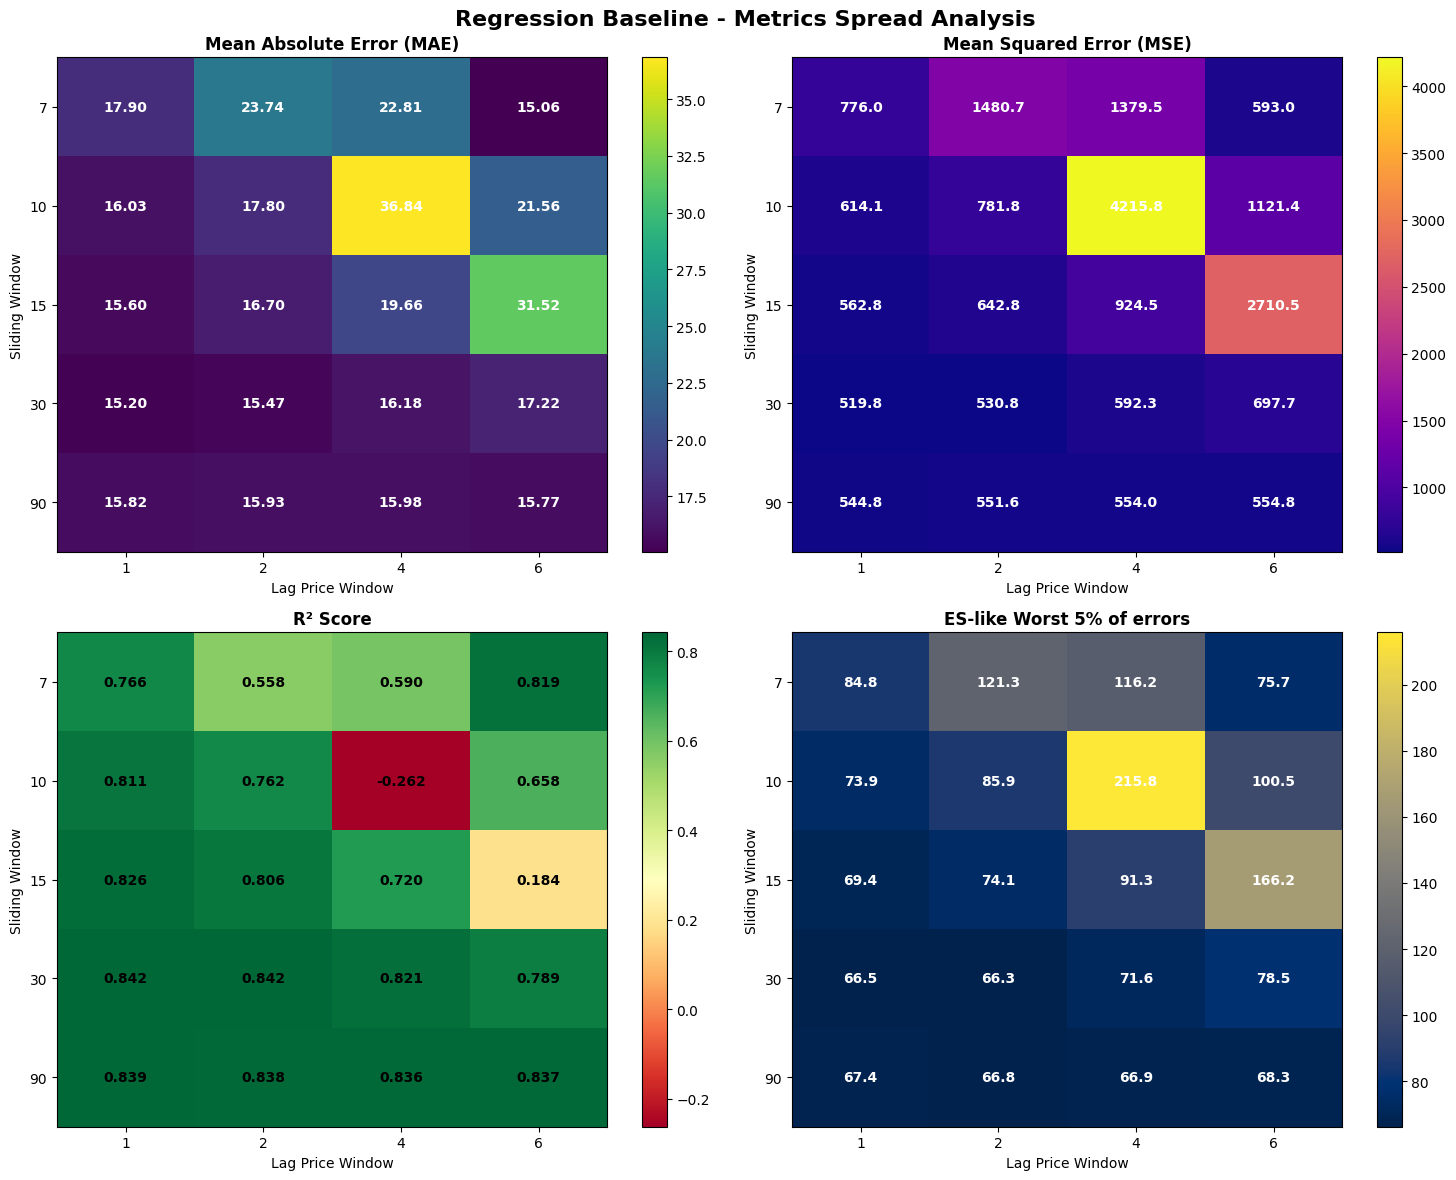

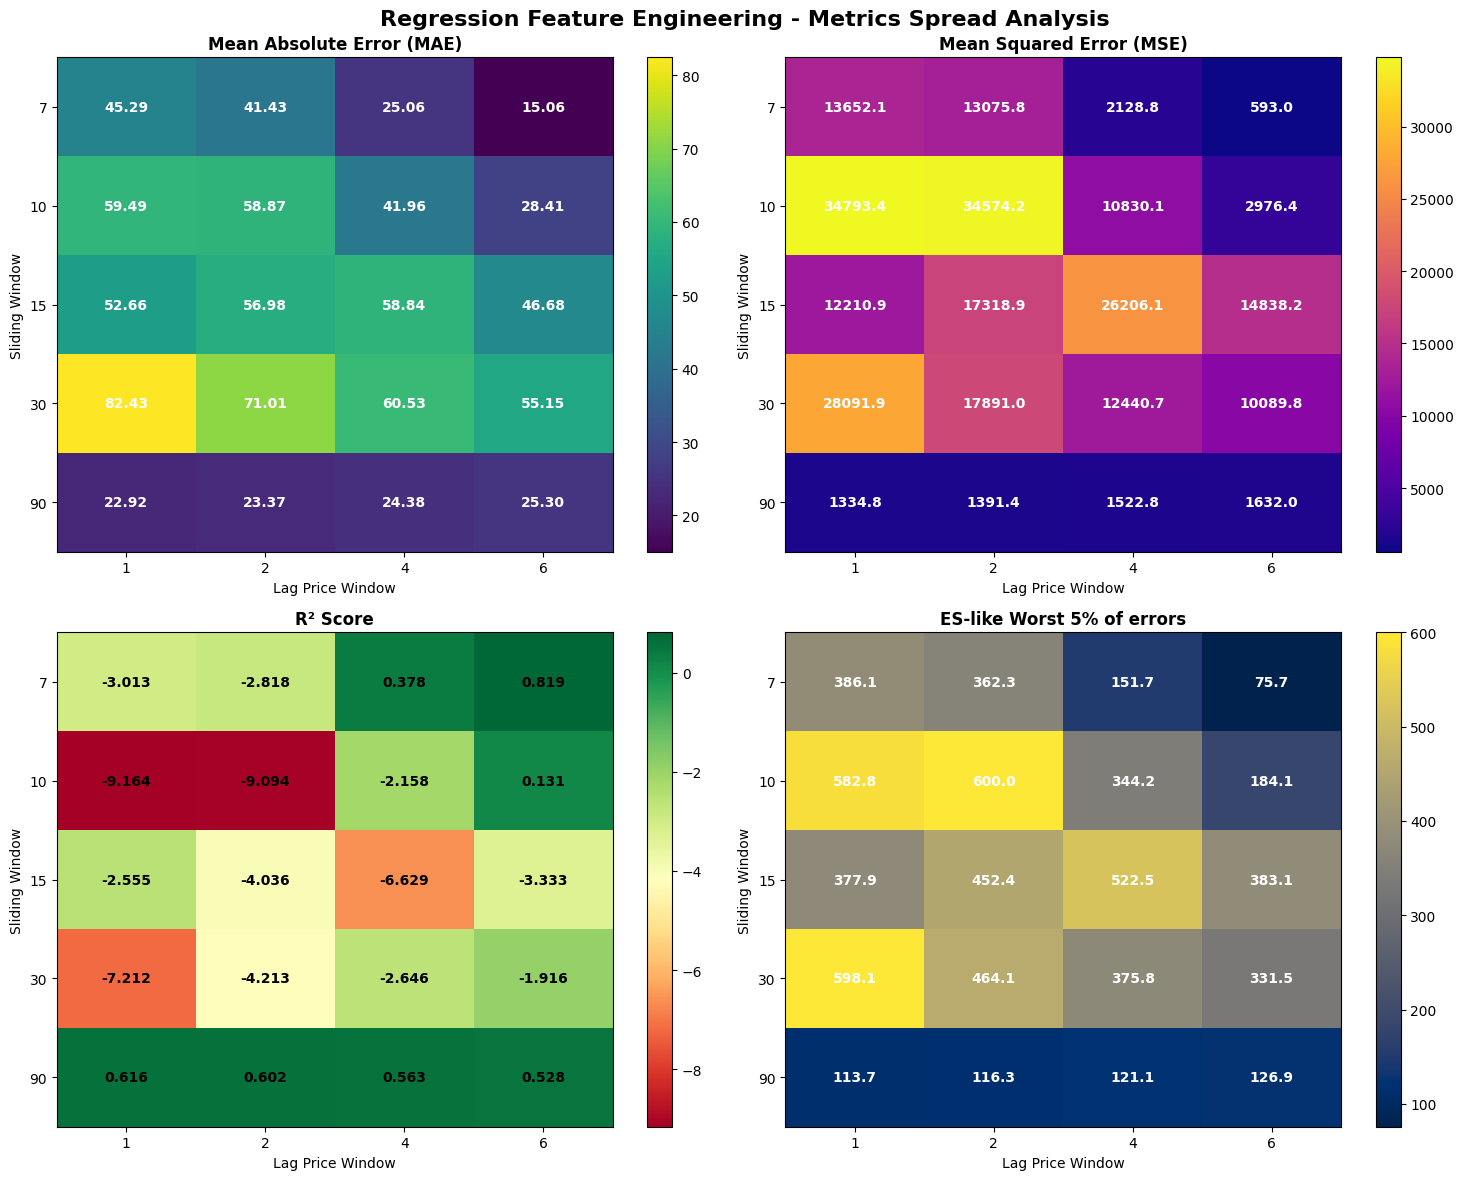

In [64]:
# Plot the spread between the best and worst metric values for each model
# Plot MAE, MSE, R², and worst error for each model

# Create a comprehensive visualization of all metrics across sliding_window and lag_price_window
def plot_metric_spreads(df, model_name, figsize=(15, 12)):
    """Plot heatmaps for each metric with sliding_window and lag_price_window as axes"""
    
    # Create pivot tables for each metric
    mae_pivot = df.pivot_table(values='mae', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    mse_pivot = df.pivot_table(values='mse', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    r2_pivot = df.pivot_table(values='r2', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    worst_error_pivot = df.pivot_table(values='worst_avg_error', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'{model_name} - Metrics Spread Analysis', fontsize=16, fontweight='bold')
    
    # MAE heatmap
    im1 = axes[0, 0].imshow(mae_pivot.values, cmap='viridis', aspect='auto')
    axes[0, 0].set_title('Mean Absolute Error (MAE)', fontweight='bold')
    axes[0, 0].set_xlabel('Lag Price Window')
    axes[0, 0].set_ylabel('Sliding Window')
    axes[0, 0].set_xticks(range(len(mae_pivot.columns)))
    axes[0, 0].set_xticklabels(mae_pivot.columns)
    axes[0, 0].set_yticks(range(len(mae_pivot.index)))
    axes[0, 0].set_yticklabels(mae_pivot.index)
    plt.colorbar(im1, ax=axes[0, 0])
    
    # Add values to cells
    for i in range(len(mae_pivot.index)):
        for j in range(len(mae_pivot.columns)):
            if not np.isnan(mae_pivot.iloc[i, j]):
                axes[0, 0].text(j, i, f'{mae_pivot.iloc[i, j]:.2f}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    # MSE heatmap
    im2 = axes[0, 1].imshow(mse_pivot.values, cmap='plasma', aspect='auto')
    axes[0, 1].set_title('Mean Squared Error (MSE)', fontweight='bold')
    axes[0, 1].set_xlabel('Lag Price Window')
    axes[0, 1].set_ylabel('Sliding Window')
    axes[0, 1].set_xticks(range(len(mse_pivot.columns)))
    axes[0, 1].set_xticklabels(mse_pivot.columns)
    axes[0, 1].set_yticks(range(len(mse_pivot.index)))
    axes[0, 1].set_yticklabels(mse_pivot.index)
    plt.colorbar(im2, ax=axes[0, 1])
    
    # Add values to cells
    for i in range(len(mse_pivot.index)):
        for j in range(len(mse_pivot.columns)):
            if not np.isnan(mse_pivot.iloc[i, j]):
                axes[0, 1].text(j, i, f'{mse_pivot.iloc[i, j]:.1f}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    # R² heatmap
    im3 = axes[1, 0].imshow(r2_pivot.values, cmap='RdYlGn', aspect='auto')
    axes[1, 0].set_title('R² Score', fontweight='bold')
    axes[1, 0].set_xlabel('Lag Price Window')
    axes[1, 0].set_ylabel('Sliding Window')
    axes[1, 0].set_xticks(range(len(r2_pivot.columns)))
    axes[1, 0].set_xticklabels(r2_pivot.columns)
    axes[1, 0].set_yticks(range(len(r2_pivot.index)))
    axes[1, 0].set_yticklabels(r2_pivot.index)
    plt.colorbar(im3, ax=axes[1, 0])
    
    # Add values to cells
    for i in range(len(r2_pivot.index)):
        for j in range(len(r2_pivot.columns)):
            if not np.isnan(r2_pivot.iloc[i, j]):
                axes[1, 0].text(j, i, f'{r2_pivot.iloc[i, j]:.3f}', 
                               ha='center', va='center', color='black', fontweight='bold')
    
    # Worst Error heatmap
    im4 = axes[1, 1].imshow(worst_error_pivot.values, cmap='cividis', aspect='auto')
    axes[1, 1].set_title('ES-like Worst 5% of errors', fontweight='bold')
    axes[1, 1].set_xlabel('Lag Price Window')
    axes[1, 1].set_ylabel('Sliding Window')
    axes[1, 1].set_xticks(range(len(worst_error_pivot.columns)))
    axes[1, 1].set_xticklabels(worst_error_pivot.columns)
    axes[1, 1].set_yticks(range(len(worst_error_pivot.index)))
    axes[1, 1].set_yticklabels(worst_error_pivot.index)
    plt.colorbar(im4, ax=axes[1, 1])
    
    # Add values to cells
    for i in range(len(worst_error_pivot.index)):
        for j in range(len(worst_error_pivot.columns)):
            if not np.isnan(worst_error_pivot.iloc[i, j]):
                axes[1, 1].text(j, i, f'{worst_error_pivot.iloc[i, j]:.1f}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    # save the figure
    plt.savefig(f'{model_name}_metrics_spread_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for all models
plot_metric_spreads(regression_baseline_ranked, 'Regression Baseline')
plot_metric_spreads(regression_fe_ranked, 'Regression Feature Engineering')

Lasso

In [37]:
# For Lasso models I need to include the 'alpha' parameter in the pivot tables
def plot_lasso_metric_spreads(df, model_name, figsize=(20, 15)):
    """Plot heatmaps for Lasso models with alpha parameter consideration"""
    
    # Get unique alpha values
    alpha_values = sorted(df['alpha'].unique())
    
    # Create subplots: 4 metrics x number of alpha values
    fig, axes = plt.subplots(4, len(alpha_values), figsize=figsize)
    fig.suptitle(f'{model_name} - Metrics by Alpha Values', fontsize=16, fontweight='bold')
    
    metrics = ['mae', 'mse', 'r2', 'worst_avg_error']
    metric_names = ['MAE', 'MSE', 'R²', 'Worst 5% Errors']
    cmaps = ['viridis', 'plasma', 'RdYlGn', 'cividis']
    
    for i, alpha in enumerate(alpha_values):
        alpha_data = df[df['alpha'] == alpha]
        
        for j, (metric, name, cmap) in enumerate(zip(metrics, metric_names, cmaps)):
            pivot = alpha_data.pivot_table(values=metric, index='sliding_window', 
                                         columns='lag_price_window', aggfunc='mean')
            
            ax = axes[j, i] if len(alpha_values) > 1 else axes[j]
            im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
            ax.set_title(f'{name} (α={alpha})', fontweight='bold')
            ax.set_xlabel('Lag Price Window')
            ax.set_ylabel('Sliding Window')
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            
            # Add colorbar
            plt.colorbar(im, ax=ax)
            
            # Add values to cells
            for row in range(len(pivot.index)):
                for col in range(len(pivot.columns)):
                    if not np.isnan(pivot.iloc[row, col]):
                        color = 'white' if metric != 'r2' else 'black'
                        decimals = 3 if metric == 'r2' else 2 if metric == 'mae' else 1
                        ax.text(col, row, f'{pivot.iloc[row, col]:.{decimals}f}', 
                               ha='center', va='center', color=color, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


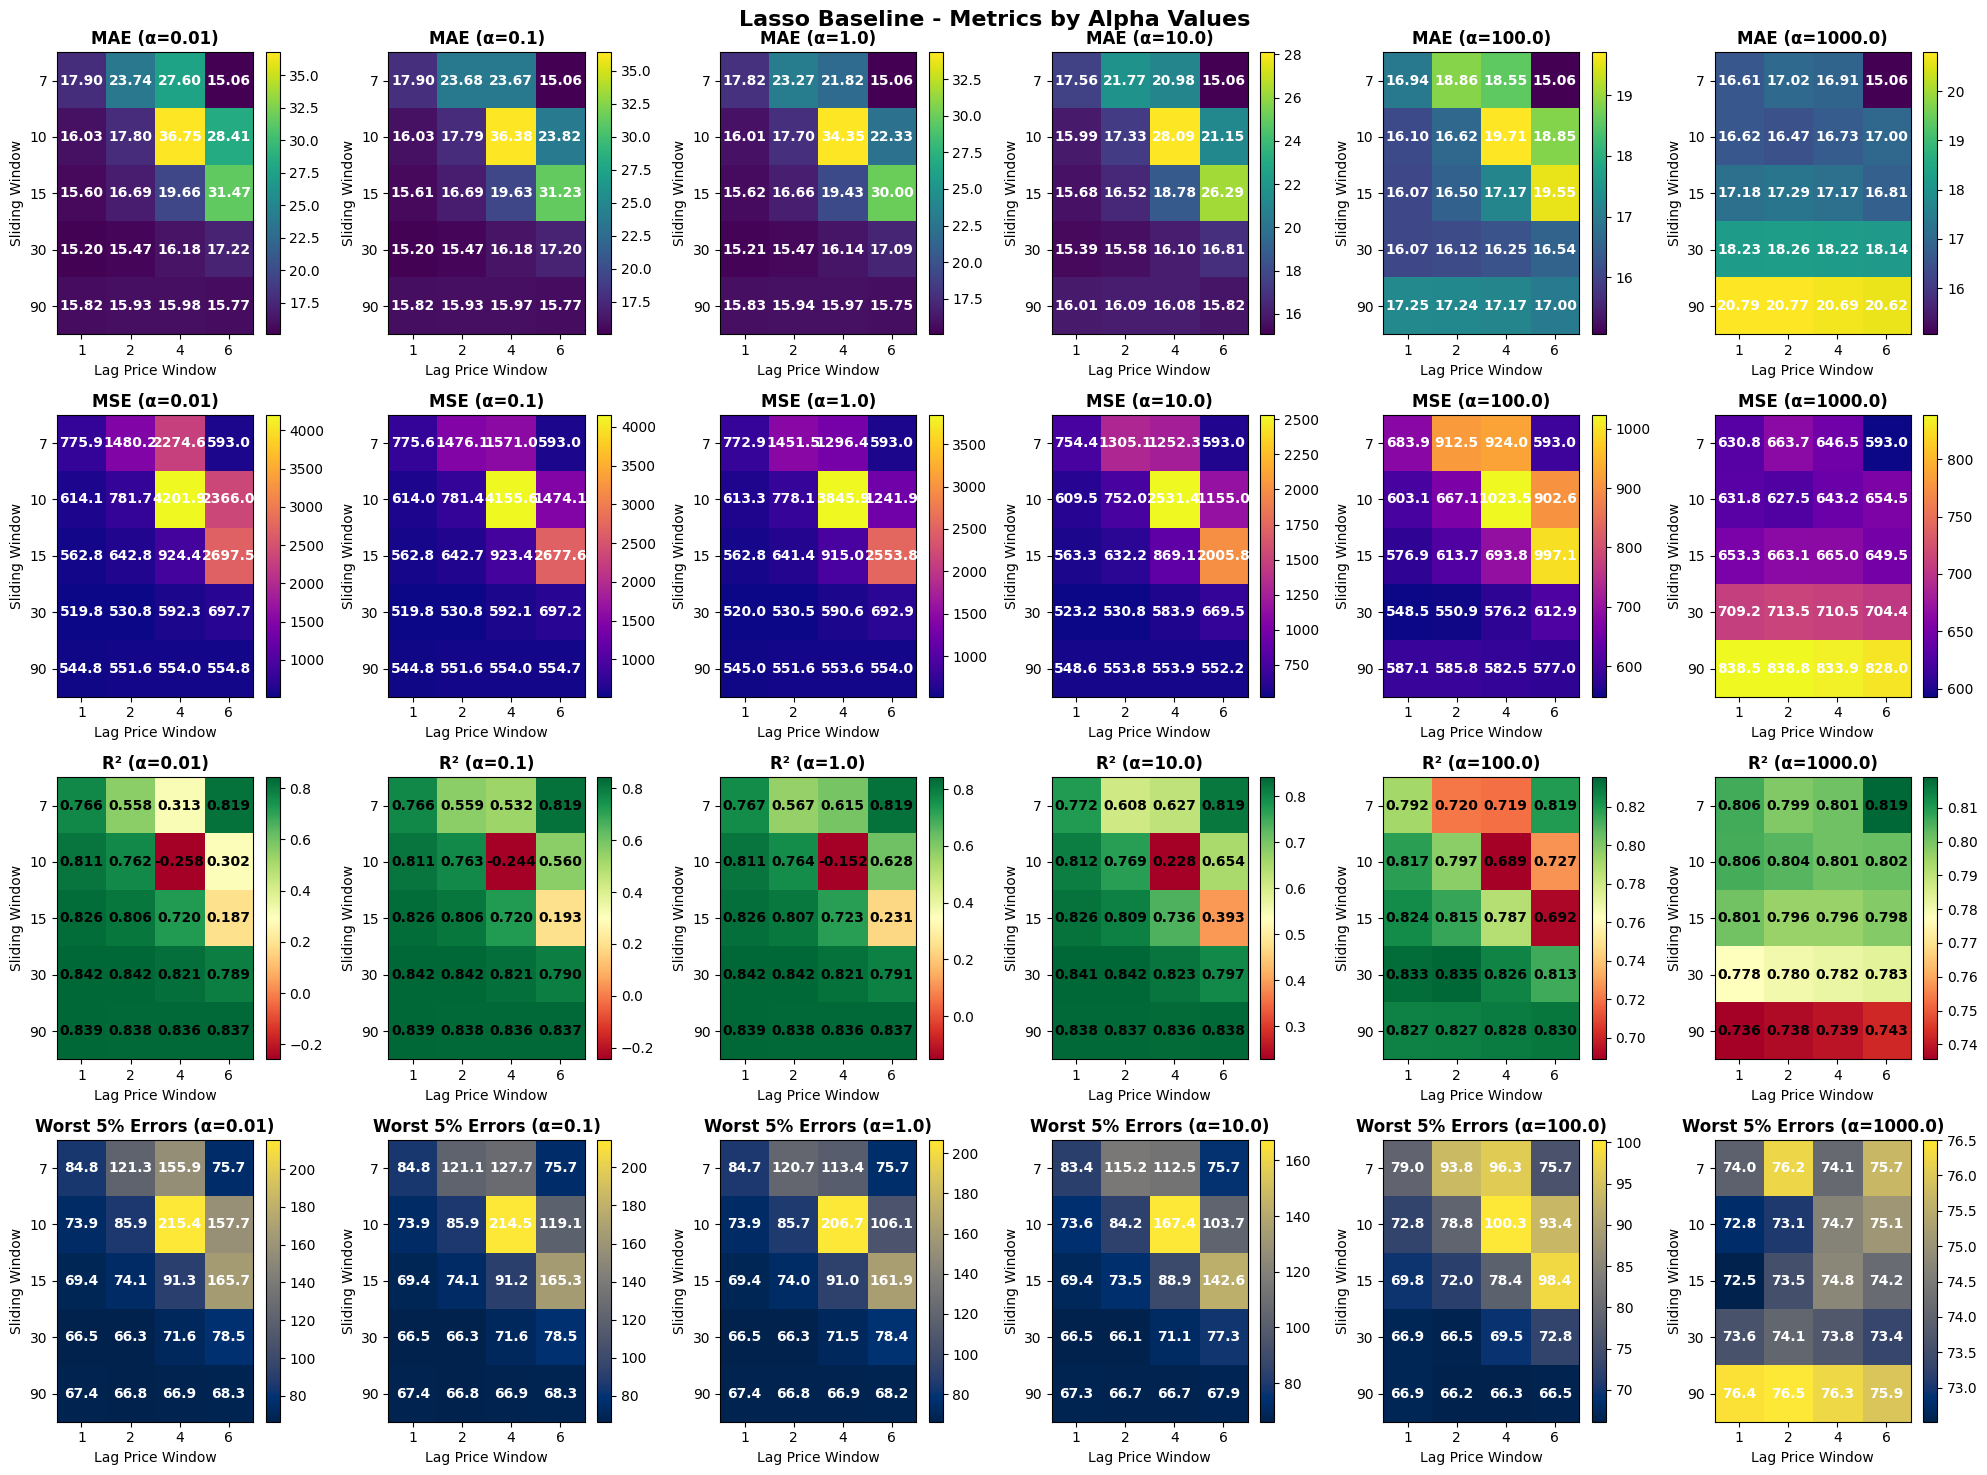

In [38]:
plot_lasso_metric_spreads(lasso_baseline_ranked, 'Lasso Baseline')

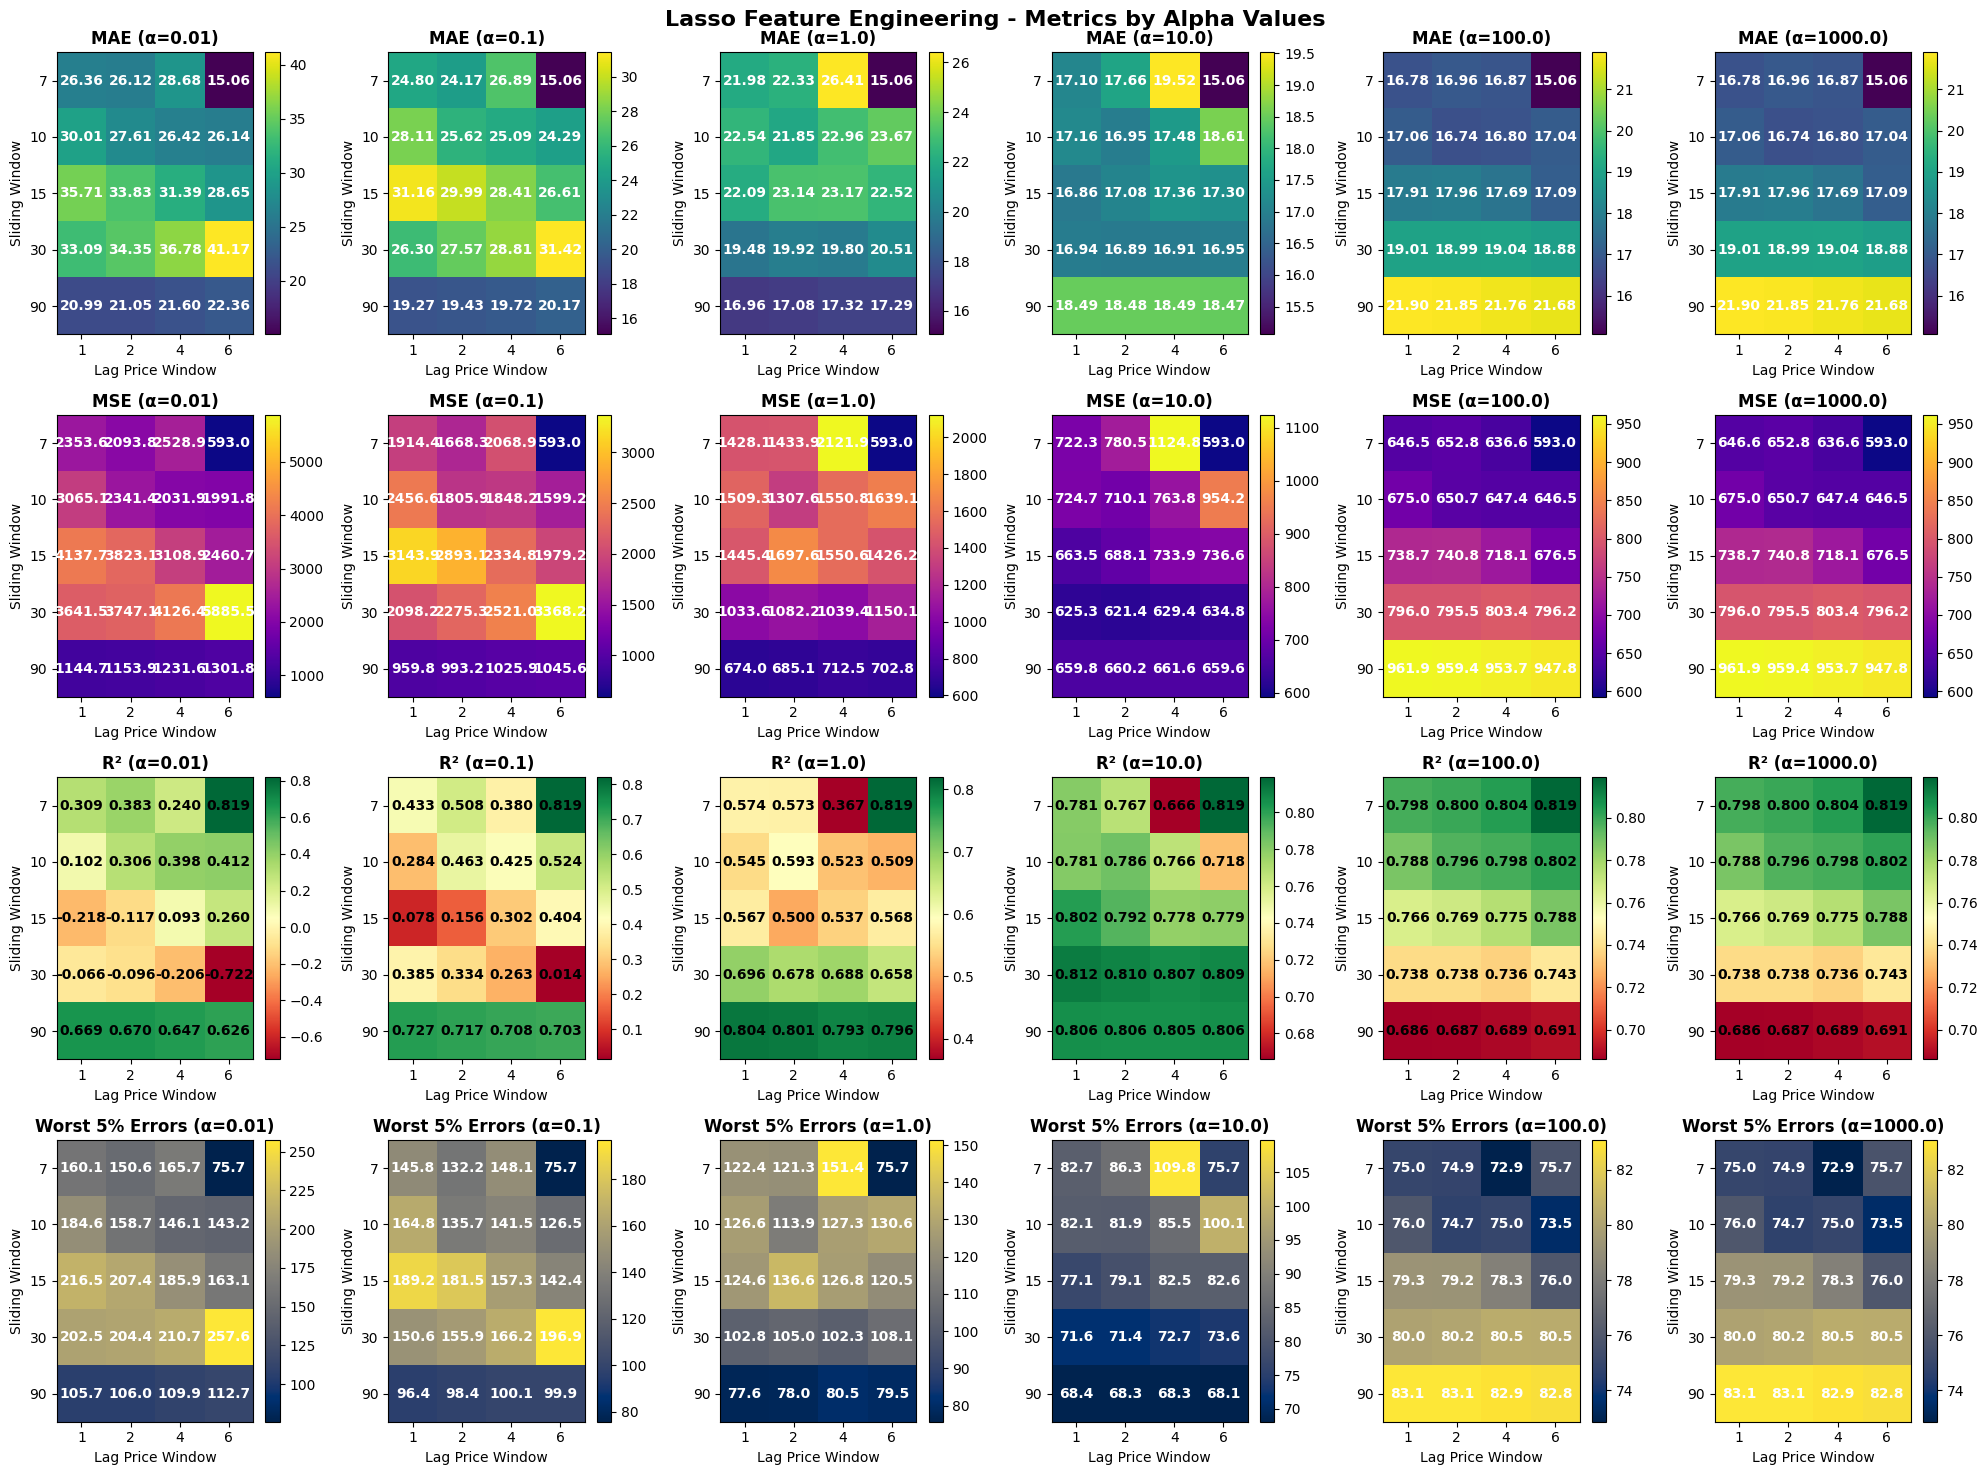

In [39]:
plot_lasso_metric_spreads(lasso_fe_ranked, 'Lasso Feature Engineering')

In [52]:
def plot_best_alpha_heatmaps(df, model_name, figsize=(15, 12)):
    """Plot heatmaps showing best alpha and corresponding metric values"""
    
    # Find best alpha for each sliding_window, lag_price_window combination
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    # Create pivot tables
    mae_pivot = best_configs.pivot_table(values='mae', index='sliding_window', columns='lag_price_window')
    alpha_pivot = best_configs.pivot_table(values='alpha', index='sliding_window', columns='lag_price_window')
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'{model_name} - Best Alpha Configurations', fontsize=16, fontweight='bold')
    
    # MAE with best alpha
    im1 = axes[0, 0].imshow(mae_pivot.values, cmap='viridis', aspect='auto')
    axes[0, 0].set_title('MAE (Best Alpha)', fontweight='bold')
    # ... [same formatting as before]
    
    # Alpha values heatmap
    im2 = axes[0, 1].imshow(alpha_pivot.values, cmap='viridis', aspect='auto')
    axes[0, 1].set_title('Best Alpha Values', fontweight='bold')
    # ... [same formatting]
    
    # Add alpha values as text
    for i in range(len(alpha_pivot.index)):
        for j in range(len(alpha_pivot.columns)):
            if not np.isnan(alpha_pivot.iloc[i, j]):
                axes[0, 1].text(j, i, f'{alpha_pivot.iloc[i, j]:.3f}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


In [166]:
def plot_lasso_best_alpha_heatmaps(df, model_name, figsize=(20, 15)):
    """Plot heatmaps showing best alpha and corresponding metric values"""
    
    # Find best alpha for each sliding_window, lag_price_window combination
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    # Create pivot tables for metrics with best alpha
    mae_pivot = best_configs.pivot_table(values='mae', index='sliding_window', columns='lag_price_window')
    mse_pivot = best_configs.pivot_table(values='mse', index='sliding_window', columns='lag_price_window')
    r2_pivot = best_configs.pivot_table(values='r2', index='sliding_window', columns='lag_price_window')
    worst_error_pivot = best_configs.pivot_table(values='worst_avg_error', index='sliding_window', columns='lag_price_window')
    alpha_pivot = best_configs.pivot_table(values='alpha', index='sliding_window', columns='lag_price_window')
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f'{model_name} - Best Alpha Configurations', fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axes = axes.flatten()
    
    # MAE with best alpha
    im1 = axes[0].imshow(mae_pivot.values, cmap='viridis', aspect='auto')
    axes[0].set_title('MAE', fontweight='bold')
    axes[0].set_xlabel('Lag Price Window')
    axes[0].set_ylabel('Sliding Window')
    axes[0].set_xticks(range(len(mae_pivot.columns)))
    axes[0].set_xticklabels(mae_pivot.columns)
    axes[0].set_yticks(range(len(mae_pivot.index)))
    axes[0].set_yticklabels(mae_pivot.index)
    plt.colorbar(im1, ax=axes[0])
    
    # Add values to cells
    for i in range(len(mae_pivot.index)):
        for j in range(len(mae_pivot.columns)):
            if not np.isnan(mae_pivot.iloc[i, j]):
                mae_val = mae_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[0].text(j, i, f'{mae_val:.2f}\n(α={alpha_val})', 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # MSE with best alpha
    im2 = axes[1].imshow(mse_pivot.values, cmap='plasma', aspect='auto')
    axes[1].set_title('MSE', fontweight='bold')
    axes[1].set_xlabel('Lag Price Window')
    axes[1].set_ylabel('Sliding Window')
    axes[1].set_xticks(range(len(mse_pivot.columns)))
    axes[1].set_xticklabels(mse_pivot.columns)
    axes[1].set_yticks(range(len(mse_pivot.index)))
    axes[1].set_yticklabels(mse_pivot.index)
    plt.colorbar(im2, ax=axes[1])
    
    for i in range(len(mse_pivot.index)):
        for j in range(len(mse_pivot.columns)):
            if not np.isnan(mse_pivot.iloc[i, j]):
                mse_val = mse_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[1].text(j, i, f'{mse_val:.1f}\n(α={alpha_val})', 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # R² with best alpha
    im3 = axes[2].imshow(r2_pivot.values, cmap='RdYlGn', aspect='auto')
    axes[2].set_title('R²', fontweight='bold')
    axes[2].set_xlabel('Lag Price Window')
    axes[2].set_ylabel('Sliding Window')
    axes[2].set_xticks(range(len(r2_pivot.columns)))
    axes[2].set_xticklabels(r2_pivot.columns)
    axes[2].set_yticks(range(len(r2_pivot.index)))
    axes[2].set_yticklabels(r2_pivot.index)
    plt.colorbar(im3, ax=axes[2])
    
    for i in range(len(r2_pivot.index)):
        for j in range(len(r2_pivot.columns)):
            if not np.isnan(r2_pivot.iloc[i, j]):
                r2_val = r2_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[2].text(j, i, f'{r2_val:.3f}\n(α={alpha_val})', 
                        ha='center', va='center', color='black', fontweight='bold', fontsize=9)
    
    # Worst Error with best alpha
    im4 = axes[3].imshow(worst_error_pivot.values, cmap='cividis', aspect='auto')
    axes[3].set_title('ES-like - Worst 5% Errors', fontweight='bold')
    axes[3].set_xlabel('Lag Price Window')
    axes[3].set_ylabel('Sliding Window')
    axes[3].set_xticks(range(len(worst_error_pivot.columns)))
    axes[3].set_xticklabels(worst_error_pivot.columns)
    axes[3].set_yticks(range(len(worst_error_pivot.index)))
    axes[3].set_yticklabels(worst_error_pivot.index)
    plt.colorbar(im4, ax=axes[3])
    
    for i in range(len(worst_error_pivot.index)):
        for j in range(len(worst_error_pivot.columns)):
            if not np.isnan(worst_error_pivot.iloc[i, j]):
                error_val = worst_error_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[3].text(j, i, f'{error_val:.1f}\n(α={alpha_val})', 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Best Alpha values heatmap
    im5 = axes[4].imshow(alpha_pivot.values, cmap='viridis', aspect='auto')
    axes[4].set_title('Best Alpha Values', fontweight='bold')
    axes[4].set_xlabel('Lag Price Window')
    axes[4].set_ylabel('Sliding Window')
    axes[4].set_xticks(range(len(alpha_pivot.columns)))
    axes[4].set_xticklabels(alpha_pivot.columns)
    axes[4].set_yticks(range(len(alpha_pivot.index)))
    axes[4].set_yticklabels(alpha_pivot.index)
    plt.colorbar(im5, ax=axes[4])
    
    # Add alpha values as text
    for i in range(len(alpha_pivot.index)):
        for j in range(len(alpha_pivot.columns)):
            if not np.isnan(alpha_pivot.iloc[i, j]):
                axes[4].text(j, i, f'{alpha_pivot.iloc[i, j]}', 
                        ha='center', va='center', color='white', fontweight='bold')
    
    # Hide the last subplot (6th position) since we only have 5 plots
    axes[5].set_visible(False)
    
    plt.tight_layout()
    # save the figure
    plt.savefig(f'{model_name}_best_alpha_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()


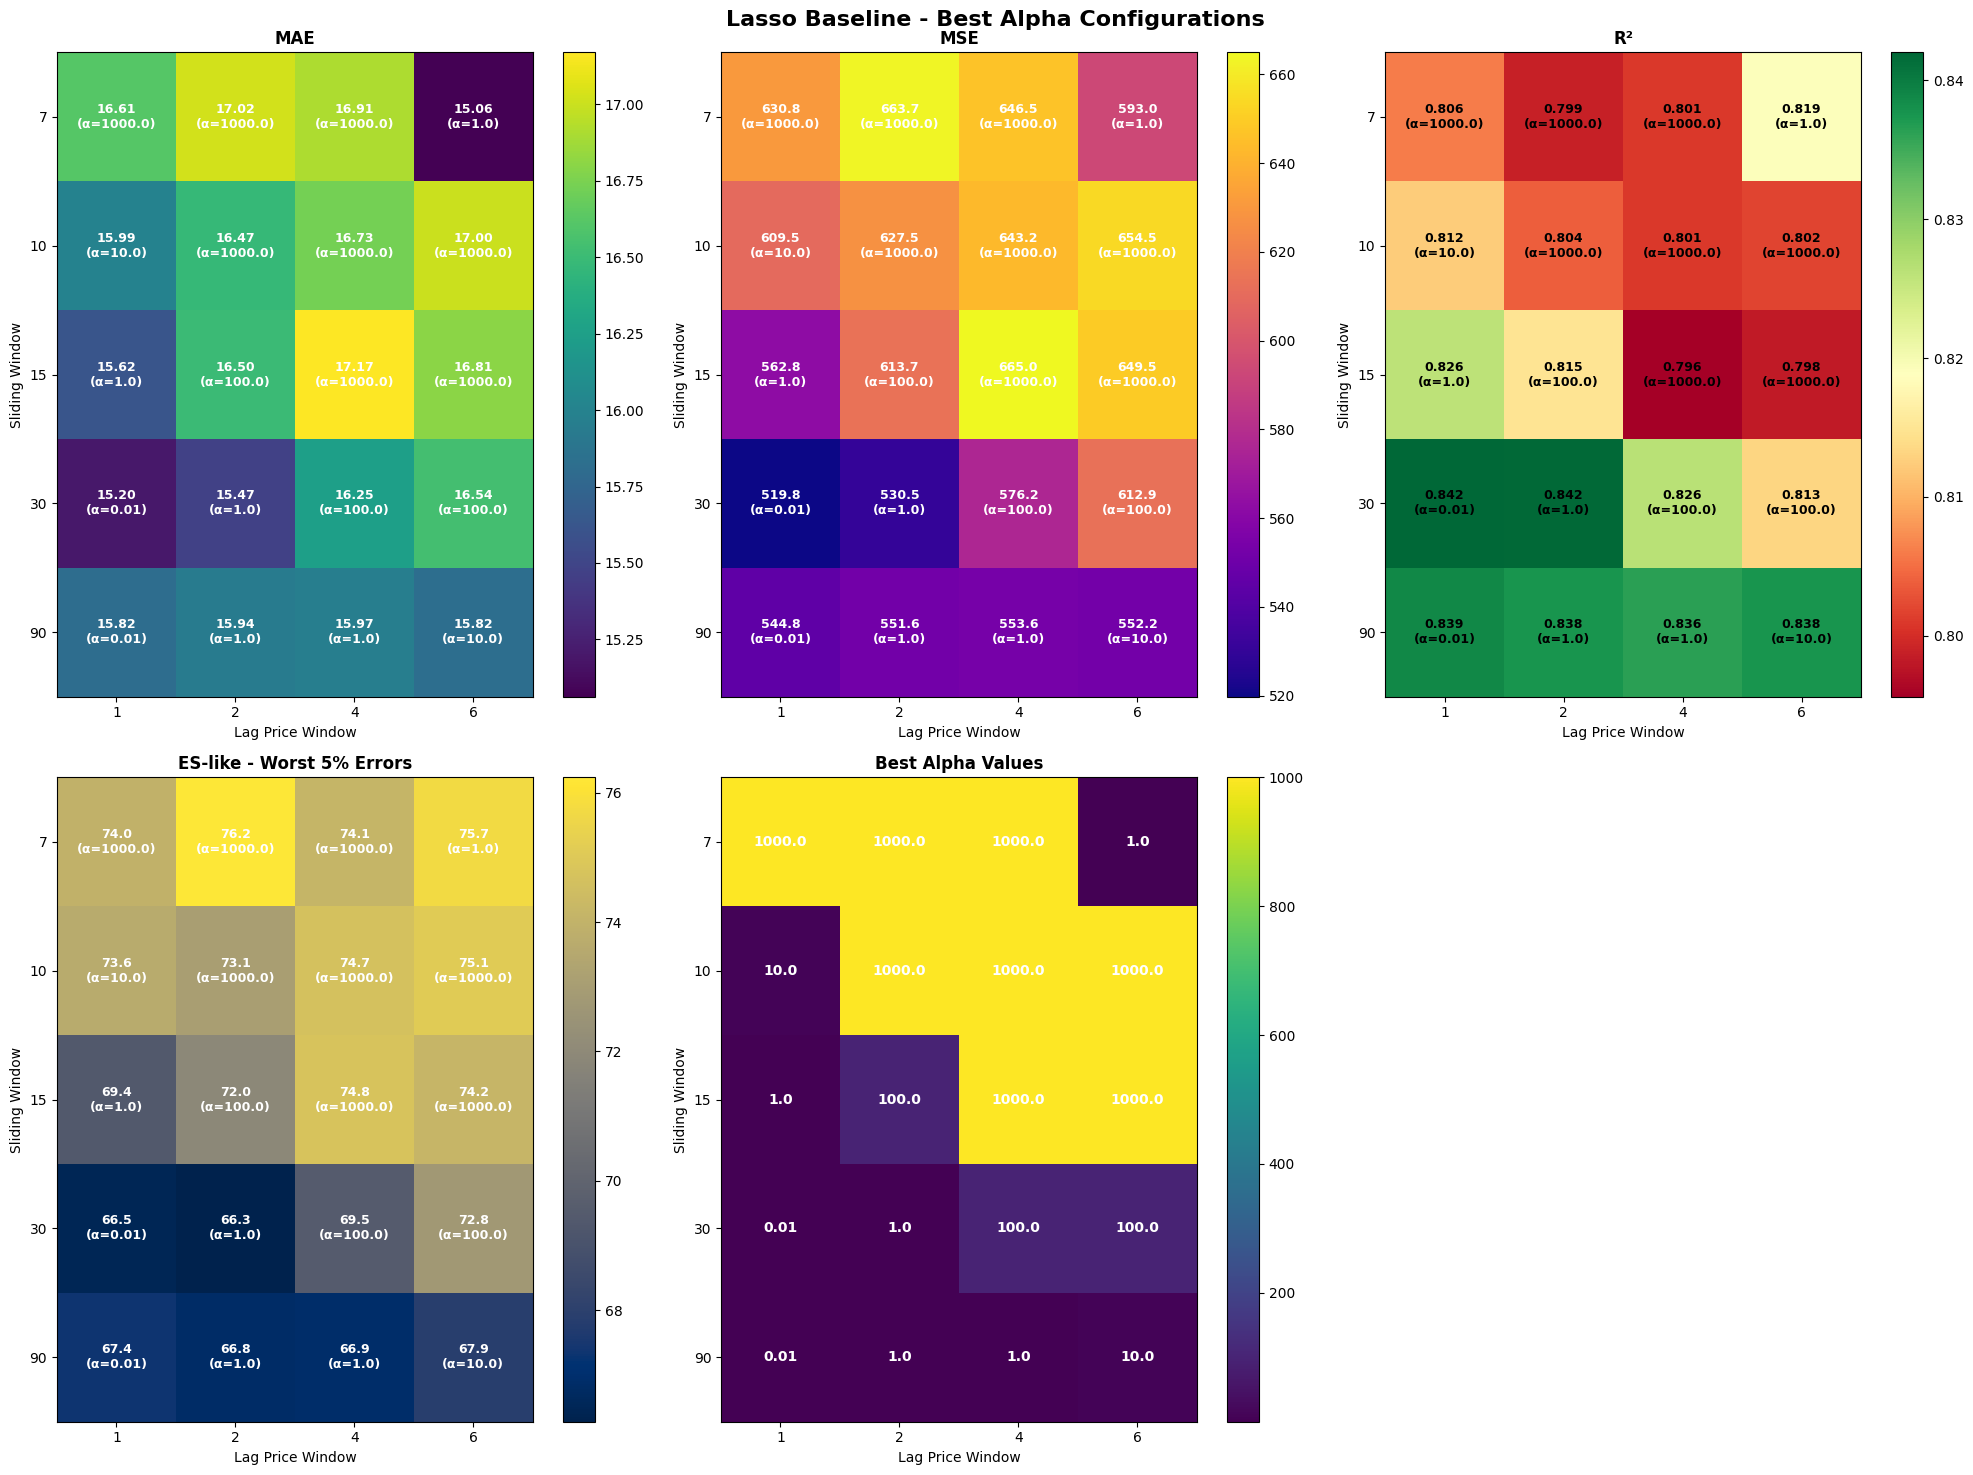

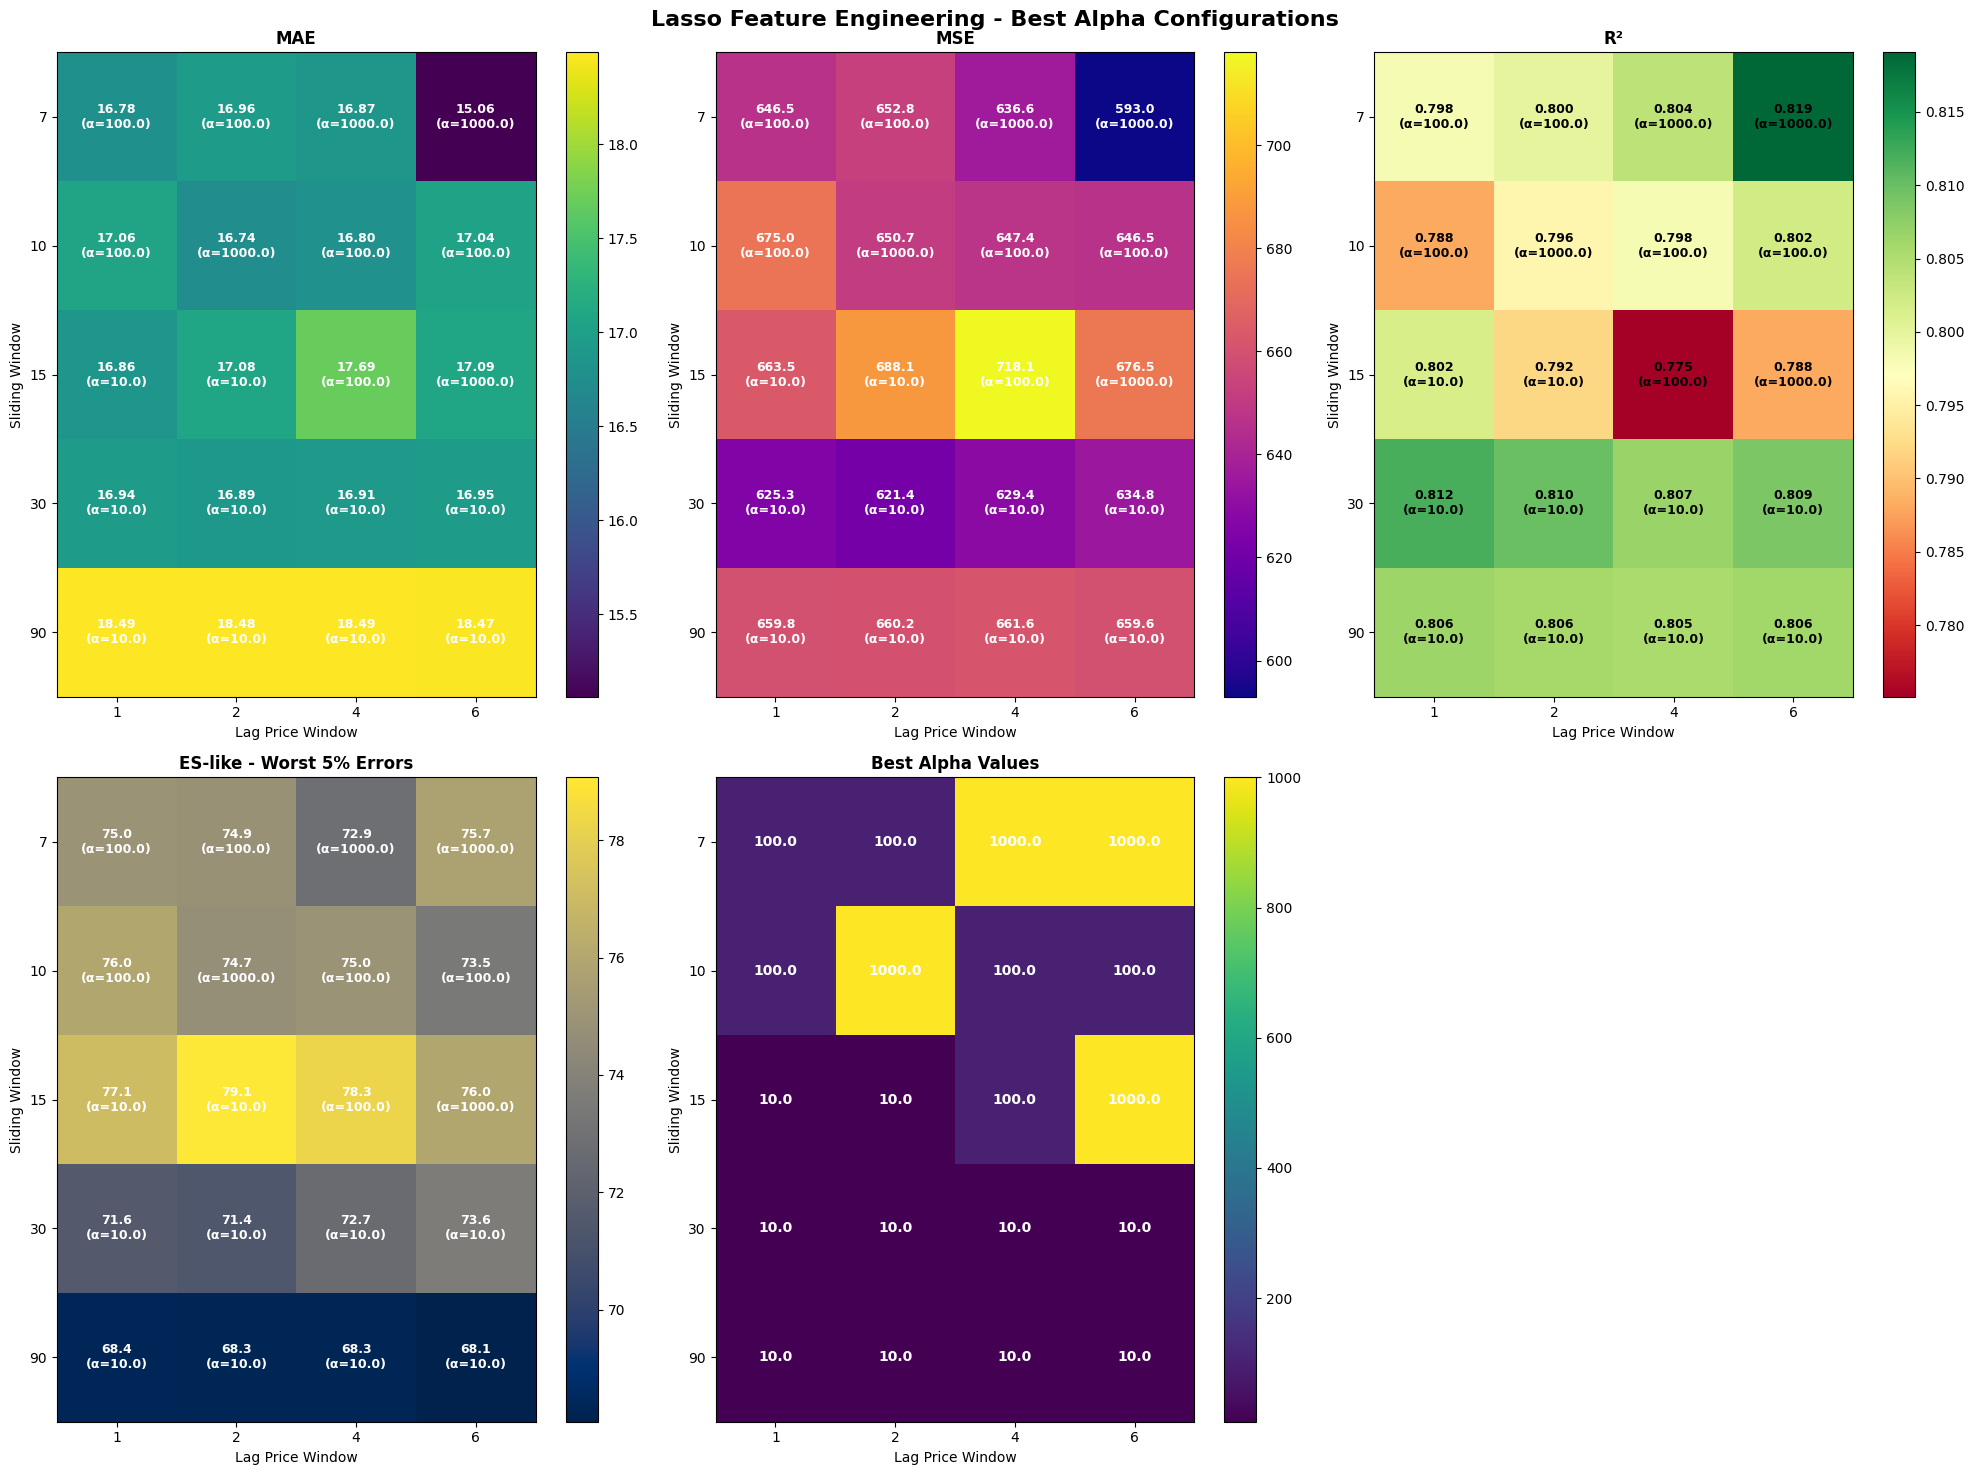

In [167]:
# Use the best alpha approach
plot_lasso_best_alpha_heatmaps(lasso_baseline_ranked, 'Lasso Baseline')
plot_lasso_best_alpha_heatmaps(lasso_fe_ranked, 'Lasso Feature Engineering')

Random Forest

In [109]:
# Recreate the complete database for random forest models
load_rf_baseline_data = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_baseline_results.csv', header=0)

load_rf_fe_data = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_fe_results.csv', header=0)

# rank the random forest models
random_forest_baseline_ranked = find_best_optimal_models(load_rf_baseline_data)
random_forest_fe_ranked = find_best_optimal_models(load_rf_fe_data)

# print the head of the ranked random forest dataframes
print("\nRandom Forest Baseline Ranked:")
print(random_forest_baseline_ranked.head())
print("\nRandom Forest FE Ranked:")
print(random_forest_fe_ranked.head())


Random Forest Baseline Ranked:
      sliding_window  lag_price_window  n_estimators  max_depth  percentile  \
1396              90                 6           400       10.0          99   
1496              90                 6           400       20.0          99   
996               90                 6           300       10.0          99   
1596              90                 6           400       30.0          99   
1296              90                 6           400        NaN          99   

      data_points         mse        mae        r2  worst_avg_error  mae_rank  \
1396         2147  607.927134  16.600169  0.816223        70.241965      35.0   
1496         2147  608.845428  16.613527  0.815946        70.296317      39.0   
996          2147  608.896811  16.593735  0.815930        70.458239      33.0   
1596         2147  608.859006  16.613670  0.815942        70.297047      40.5   
1296         2147  608.859006  16.613670  0.815942        70.297047      40.5   

      

In [172]:
def plot_rf_best_config_heatmaps(df, model_name, figsize=(25, 15)):
    """Plot heatmaps showing best RF configuration and corresponding metric values"""
    
    # Find best configuration for each sliding_window, lag_price_window combination
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    # Create pivot tables for metrics with best configuration
    mae_pivot = best_configs.pivot_table(values='mae', index='sliding_window', columns='lag_price_window')
    mse_pivot = best_configs.pivot_table(values='mse', index='sliding_window', columns='lag_price_window')
    r2_pivot = best_configs.pivot_table(values='r2', index='sliding_window', columns='lag_price_window')
    worst_error_pivot = best_configs.pivot_table(values='worst_avg_error', index='sliding_window', columns='lag_price_window')
    n_estimators_pivot = best_configs.pivot_table(values='n_estimators', index='sliding_window', columns='lag_price_window')
    max_depth_pivot = best_configs.pivot_table(values='max_depth', index='sliding_window', columns='lag_price_window')
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f'{model_name} - Best Configuration Analysis', fontsize=16, fontweight='bold')
    
    # MAE with best config
    im1 = axes[0, 0].imshow(mae_pivot.values, cmap='viridis', aspect='auto')
    axes[0, 0].set_title('MAE (Best Config)', fontweight='bold')
    axes[0, 0].set_xlabel('Lag Price Window')
    axes[0, 0].set_ylabel('Sliding Window')
    axes[0, 0].set_xticks(range(len(mae_pivot.columns)))
    axes[0, 0].set_xticklabels(mae_pivot.columns)
    axes[0, 0].set_yticks(range(len(mae_pivot.index)))
    axes[0, 0].set_yticklabels(mae_pivot.index)
    plt.colorbar(im1, ax=axes[0, 0])
    
    for i in range(len(mae_pivot.index)):
        for j in range(len(mae_pivot.columns)):
            if not np.isnan(mae_pivot.iloc[i, j]):
                mae_val = mae_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[0, 0].text(j, i, f'{mae_val:.2f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # MSE with best config
    im2 = axes[0, 1].imshow(mse_pivot.values, cmap='plasma', aspect='auto')
    axes[0, 1].set_title('MSE (Best Config)', fontweight='bold')
    axes[0, 1].set_xlabel('Lag Price Window')
    axes[0, 1].set_ylabel('Sliding Window')
    axes[0, 1].set_xticks(range(len(mse_pivot.columns)))
    axes[0, 1].set_xticklabels(mse_pivot.columns)
    axes[0, 1].set_yticks(range(len(mse_pivot.index)))
    axes[0, 1].set_yticklabels(mse_pivot.index)
    plt.colorbar(im2, ax=axes[0, 1])
    
    for i in range(len(mse_pivot.index)):
        for j in range(len(mse_pivot.columns)):
            if not np.isnan(mse_pivot.iloc[i, j]):
                mse_val = mse_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[0, 1].text(j, i, f'{mse_val:.1f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # R² with best config
    im3 = axes[0, 2].imshow(r2_pivot.values, cmap='RdYlGn', aspect='auto')
    axes[0, 2].set_title('R² (Best Config)', fontweight='bold')
    axes[0, 2].set_xlabel('Lag Price Window')
    axes[0, 2].set_ylabel('Sliding Window')
    axes[0, 2].set_xticks(range(len(r2_pivot.columns)))
    axes[0, 2].set_xticklabels(r2_pivot.columns)
    axes[0, 2].set_yticks(range(len(r2_pivot.index)))
    axes[0, 2].set_yticklabels(r2_pivot.index)
    plt.colorbar(im3, ax=axes[0, 2])
    
    for i in range(len(r2_pivot.index)):
        for j in range(len(r2_pivot.columns)):
            if not np.isnan(r2_pivot.iloc[i, j]):
                r2_val = r2_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[0, 2].text(j, i, f'{r2_val:.3f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='black', fontweight='bold', fontsize=9)
    
    # Worst Error with best config
    im4 = axes[1, 0].imshow(worst_error_pivot.values, cmap='cividis', aspect='auto')
    axes[1, 0].set_title('ES-like Worst 5% Errors (Best Config)', fontweight='bold')
    axes[1, 0].set_xlabel('Lag Price Window')
    axes[1, 0].set_ylabel('Sliding Window')
    axes[1, 0].set_xticks(range(len(worst_error_pivot.columns)))
    axes[1, 0].set_xticklabels(worst_error_pivot.columns)
    axes[1, 0].set_yticks(range(len(worst_error_pivot.index)))
    axes[1, 0].set_yticklabels(worst_error_pivot.index)
    plt.colorbar(im4, ax=axes[1, 0])
    
    for i in range(len(worst_error_pivot.index)):
        for j in range(len(worst_error_pivot.columns)):
            if not np.isnan(worst_error_pivot.iloc[i, j]):
                error_val = worst_error_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[1, 0].text(j, i, f'{error_val:.1f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Best n_estimators heatmap
    im5 = axes[1, 1].imshow(n_estimators_pivot.values, cmap='viridis', aspect='auto')
    axes[1, 1].set_title('Best n_estimators', fontweight='bold')
    axes[1, 1].set_xlabel('Lag Price Window')
    axes[1, 1].set_ylabel('Sliding Window')
    axes[1, 1].set_xticks(range(len(n_estimators_pivot.columns)))
    axes[1, 1].set_xticklabels(n_estimators_pivot.columns)
    axes[1, 1].set_yticks(range(len(n_estimators_pivot.index)))
    axes[1, 1].set_yticklabels(n_estimators_pivot.index)
    plt.colorbar(im5, ax=axes[1, 1])
    
    for i in range(len(n_estimators_pivot.index)):
        for j in range(len(n_estimators_pivot.columns)):
            if not np.isnan(n_estimators_pivot.iloc[i, j]):
                axes[1, 1].text(j, i, f'{int(n_estimators_pivot.iloc[i, j])}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    # Best max_depth heatmap
    im6 = axes[1, 2].imshow(max_depth_pivot.values, cmap='plasma', aspect='auto')
    axes[1, 2].set_title('Best max_depth', fontweight='bold')
    axes[1, 2].set_xlabel('Lag Price Window')
    axes[1, 2].set_ylabel('Sliding Window')
    axes[1, 2].set_xticks(range(len(max_depth_pivot.columns)))
    axes[1, 2].set_xticklabels(max_depth_pivot.columns)
    axes[1, 2].set_yticks(range(len(max_depth_pivot.index)))
    axes[1, 2].set_yticklabels(max_depth_pivot.index)
    plt.colorbar(im6, ax=axes[1, 2])
    
    for i in range(len(max_depth_pivot.index)):
        for j in range(len(max_depth_pivot.columns)):
            if not np.isnan(max_depth_pivot.iloc[i, j]):
                depth_val = max_depth_pivot.iloc[i, j]
                # Handle different representations of None/unlimited depth
                if pd.isna(depth_val) or depth_val == 0 or str(depth_val).lower() == 'none':
                    display_val = 'None'
                else:
                    display_val = f'{int(depth_val)}'
                axes[1, 2].text(j, i, display_val, 
                               ha='center', va='center', color='white', fontweight='bold')
            else:
                # If the pivot value itself is NaN, still show 'None'
                axes[1, 2].text(j, i, 'None', 
                               ha='center', va='center', color='black', fontweight='bold')
    
    plt.tight_layout()
    # save the figure
    plt.savefig(f'{model_name}_best_config_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()

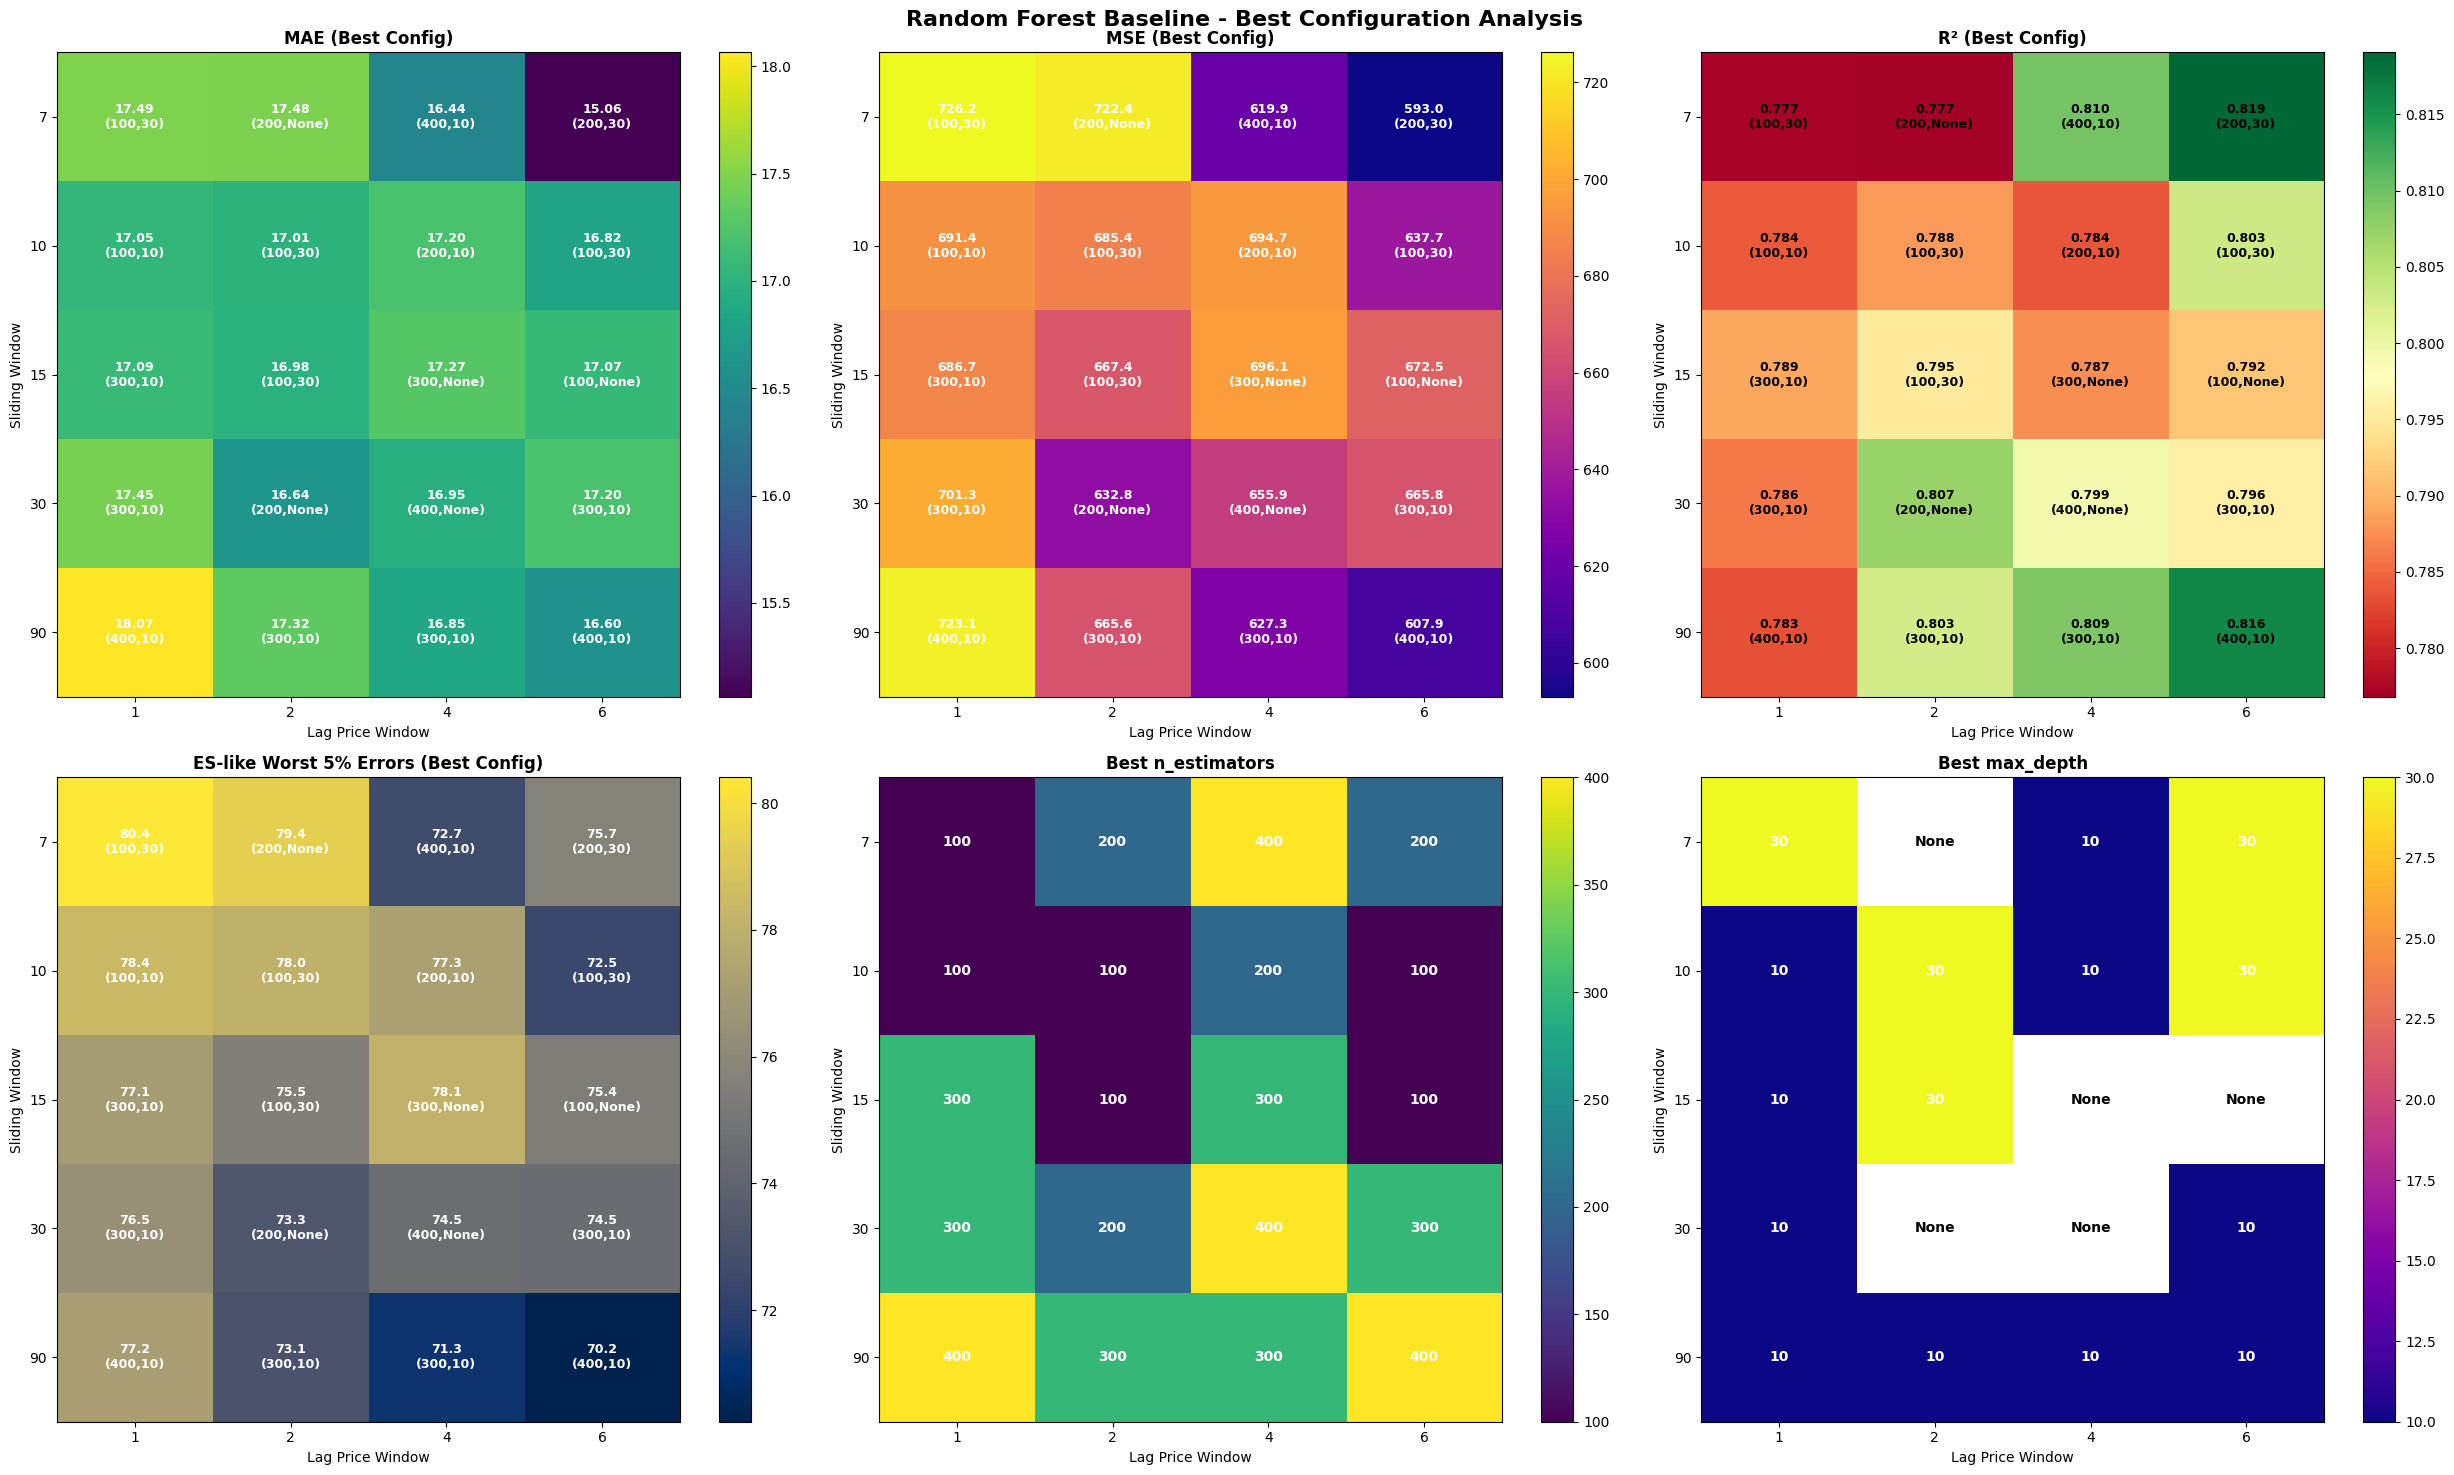

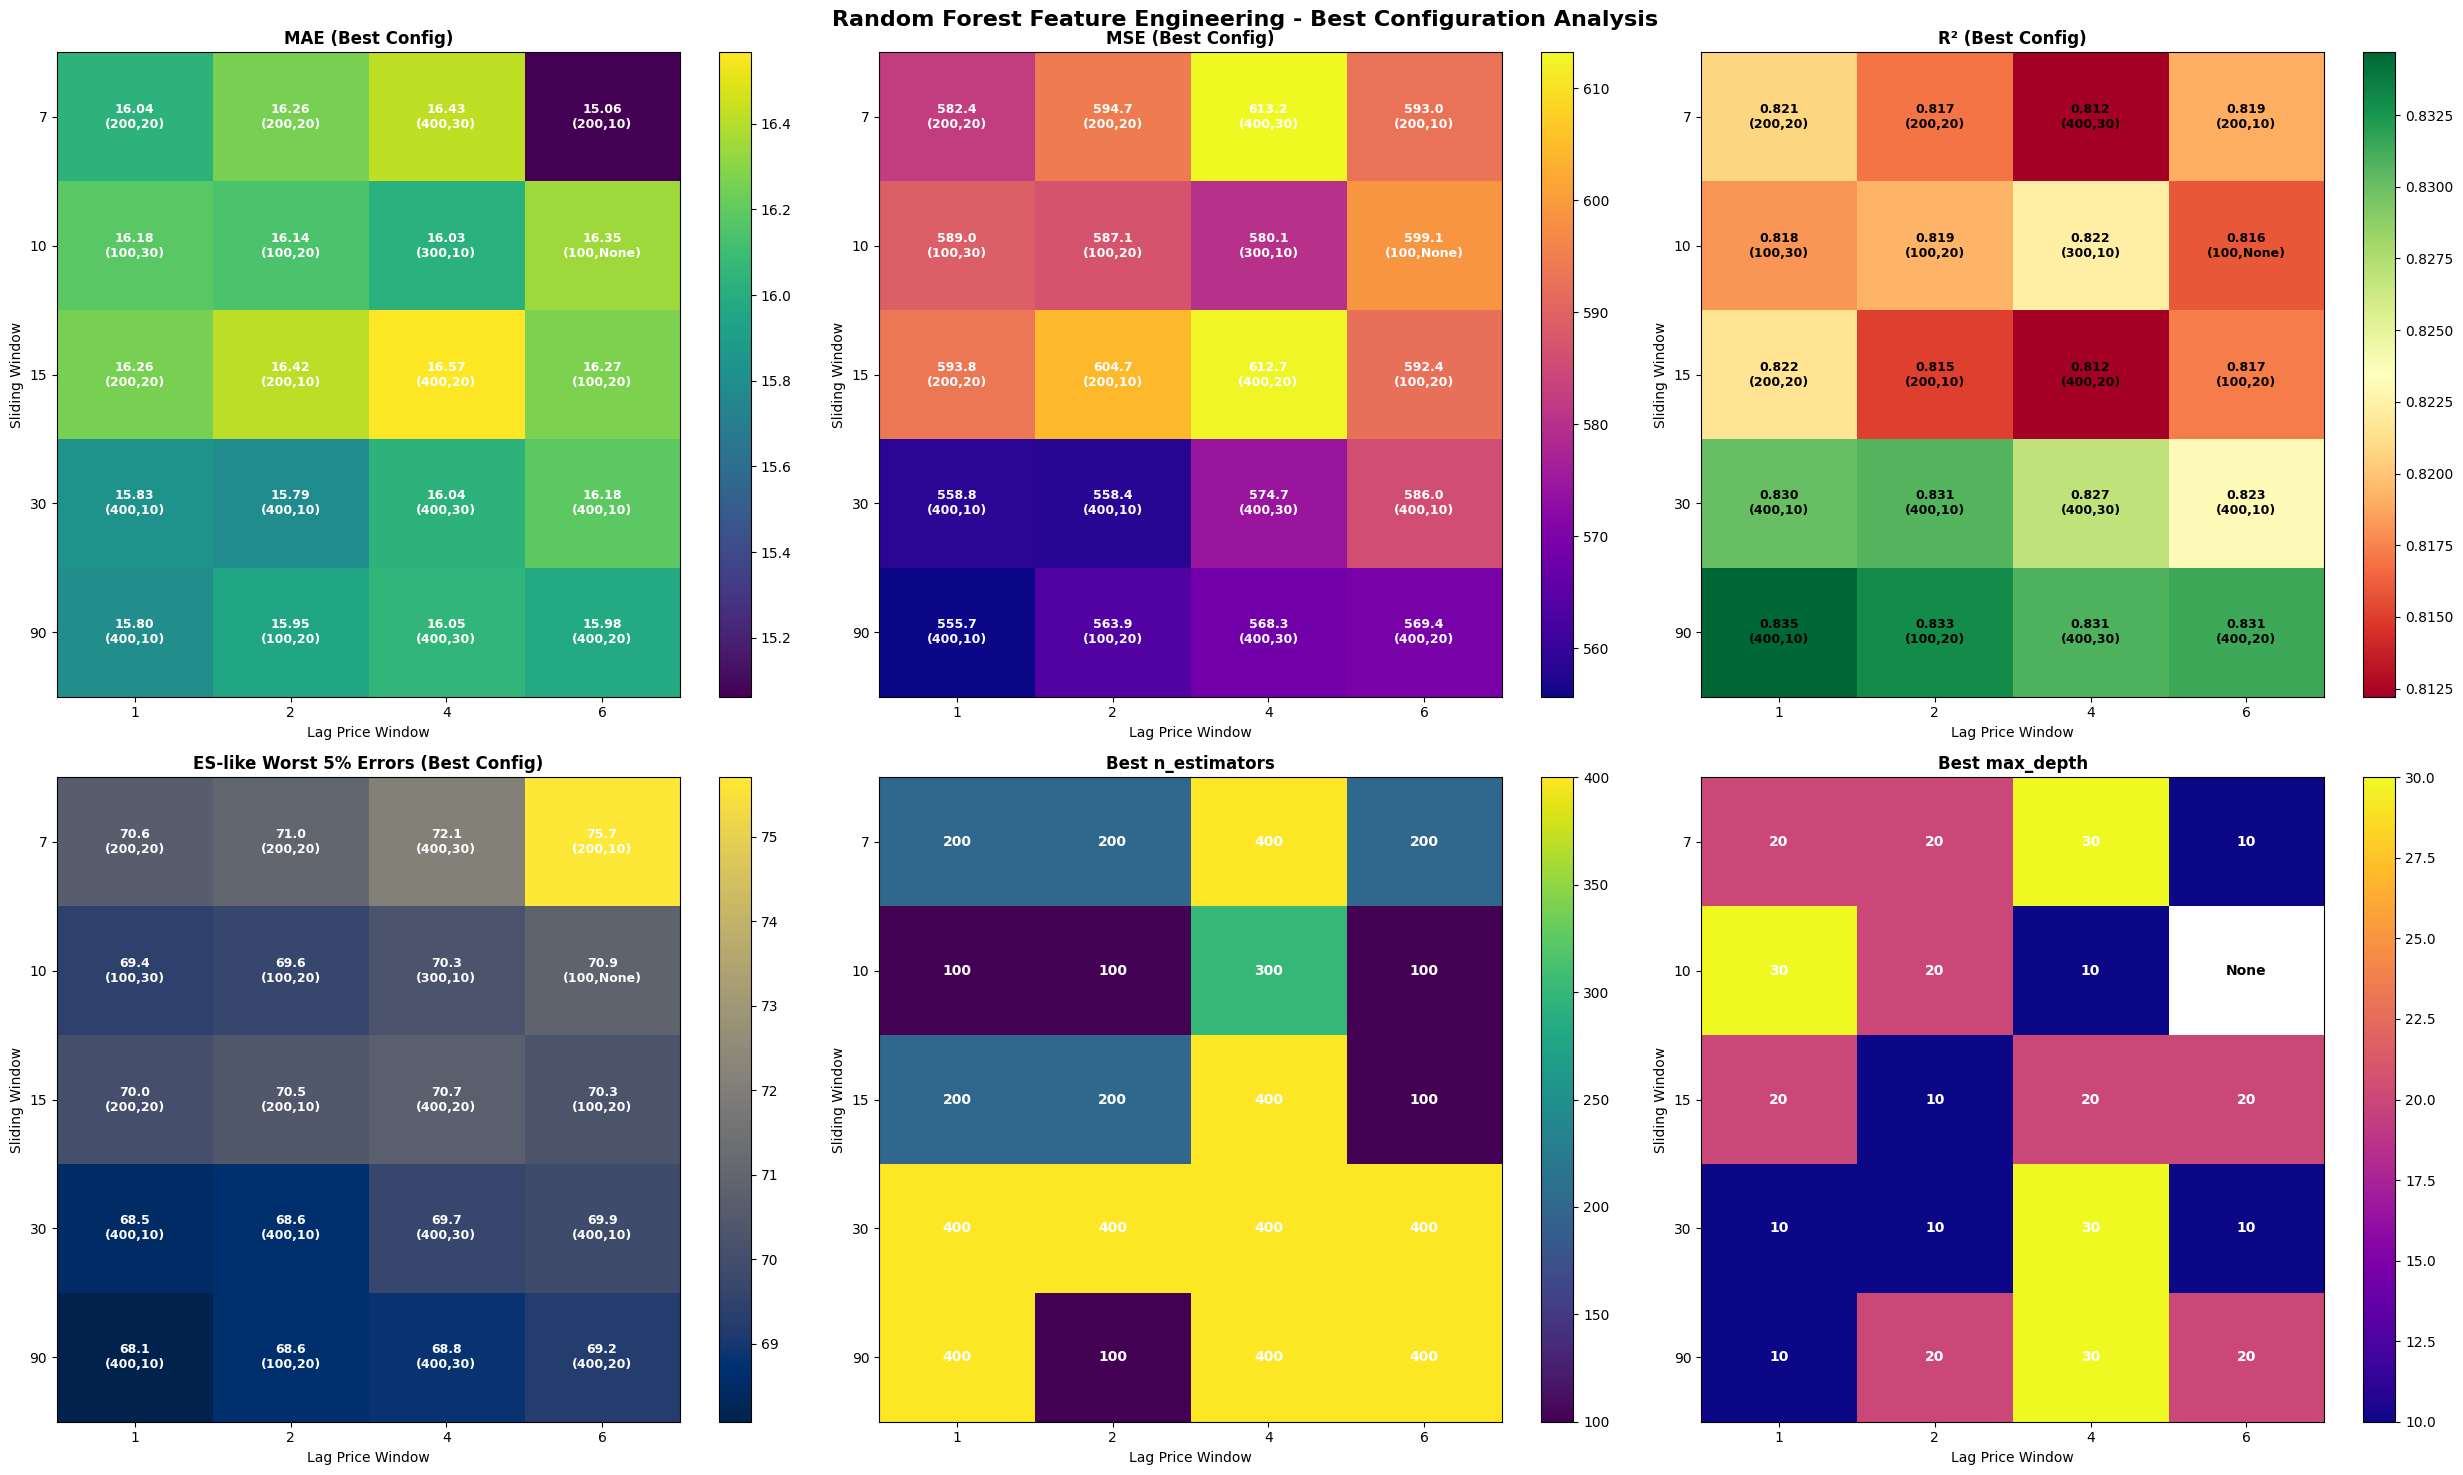

In [173]:
# Comprehensive Random Forest analysis
plot_rf_best_config_heatmaps(random_forest_baseline_ranked, 'Random Forest Baseline')
plot_rf_best_config_heatmaps(random_forest_fe_ranked, 'Random Forest Feature Engineering')

In [142]:
# Additional function for hyperparameter distribution analysis
def plot_rf_hyperparameter_analysis(df, model_name, figsize=(20, 6)):
    """Plot detailed hyperparameter distribution and interaction analysis"""
    
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(f'{model_name} - Hyperparameter Analysis', fontsize=16, fontweight='bold')
    
    # Distribution of best n_estimators
    axes[0].hist(best_configs['n_estimators'], bins=len(best_configs['n_estimators'].unique()), 
                alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].set_title('Distribution of Best n_estimators', fontweight='bold')
    axes[0].set_xlabel('n_estimators')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
    
    # Distribution of best max_depth
    max_depth_counts = best_configs['max_depth'].value_counts().sort_index()
    axes[1].bar(range(len(max_depth_counts)), max_depth_counts.values, 
               alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1].set_title('Distribution of Best max_depth', fontweight='bold')
    axes[1].set_xlabel('max_depth')
    axes[1].set_ylabel('Frequency')
    axes[1].set_xticks(range(len(max_depth_counts)))
    axes[1].set_xticklabels([f'{int(x)}' if not pd.isna(x) else 'None' for x in max_depth_counts.index])
    axes[1].grid(True, alpha=0.3)
    
    # Hyperparameter combination heatmap
    combo_counts = best_configs.groupby(['n_estimators', 'max_depth']).size().unstack(fill_value=0)
    im = axes[2].imshow(combo_counts.values, cmap='Blues', aspect='auto')
    axes[2].set_title('Best Hyperparameter Combinations', fontweight='bold')
    axes[2].set_xlabel('max_depth')
    axes[2].set_ylabel('n_estimators')
    axes[2].set_xticks(range(len(combo_counts.columns)))
    axes[2].set_xticklabels([f'{int(x)}' if not pd.isna(x) else 'None' for x in combo_counts.columns])
    axes[2].set_yticks(range(len(combo_counts.index)))
    axes[2].set_yticklabels(combo_counts.index)
    plt.colorbar(im, ax=axes[2])
    
    plt.tight_layout()
    plt.savefig(f'{model_name}_hyperparameter_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


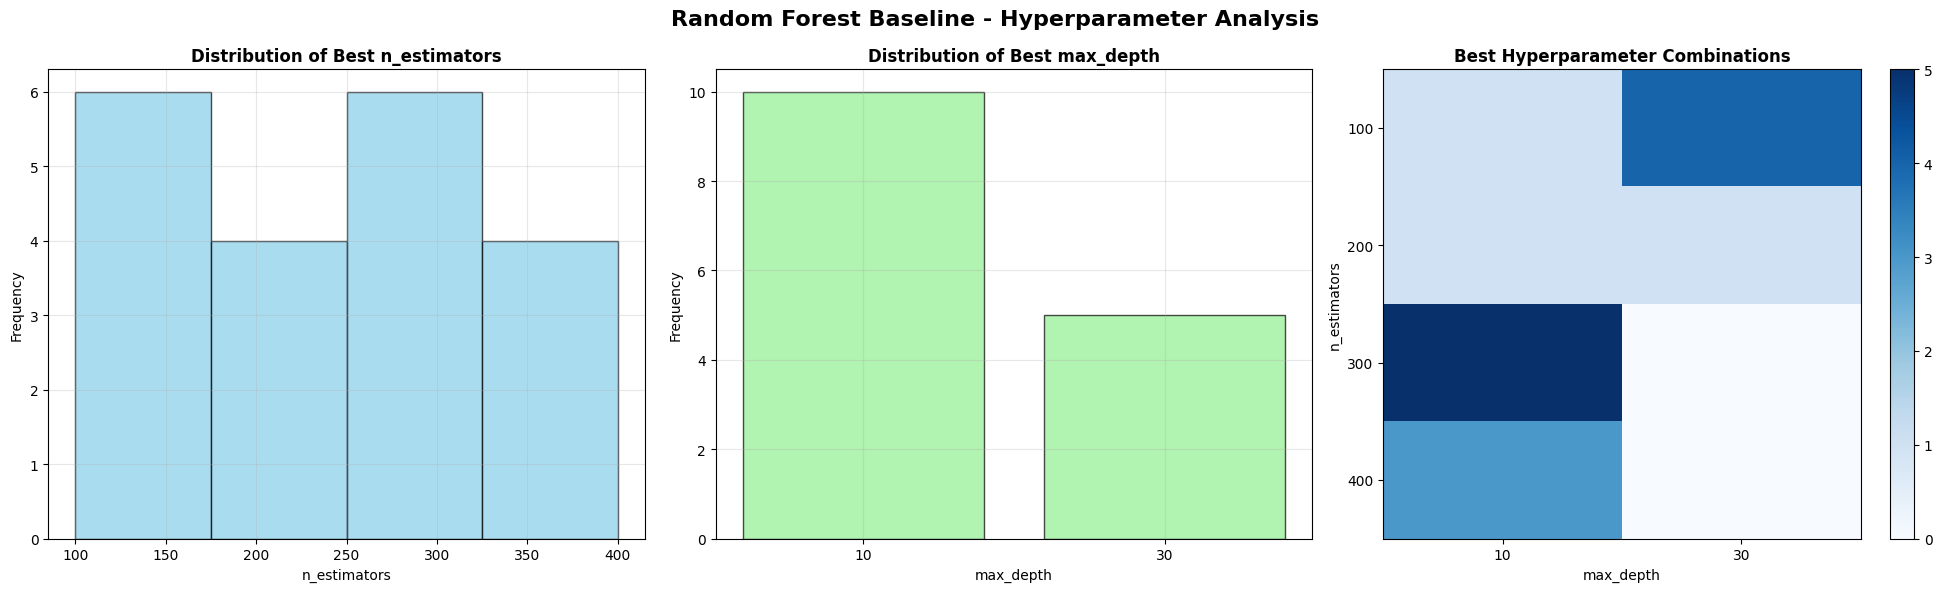

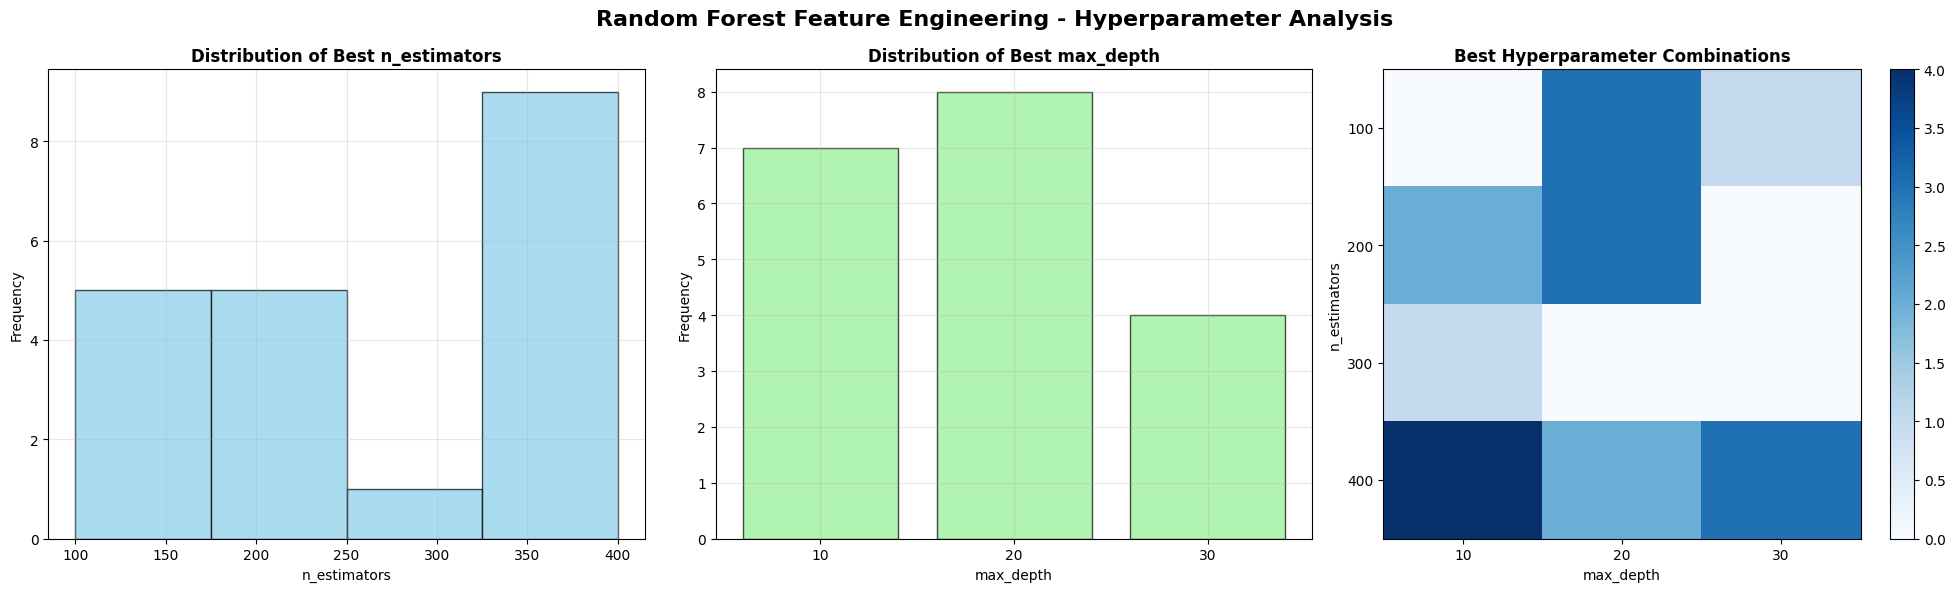

In [143]:
# Additional hyperparameter analysis
plot_rf_hyperparameter_analysis(random_forest_baseline_ranked, 'Random Forest Baseline')
plot_rf_hyperparameter_analysis(random_forest_fe_ranked, 'Random Forest Feature Engineering')

In [157]:
def plot_rf_annotated_heatmap(df, model_name, metric='mae', figsize=(15, 12)):
    """Plot heatmap with hyperparameter annotations in cells"""
    
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    metric_pivot = best_configs.pivot_table(values=metric, index='sliding_window', columns='lag_price_window')
    n_est_pivot = best_configs.pivot_table(values='n_estimators', index='sliding_window', columns='lag_price_window')
    depth_pivot = best_configs.pivot_table(values='max_depth', index='sliding_window', columns='lag_price_window')
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(metric_pivot.values, cmap='viridis', aspect='auto')
    ax.set_title(f'{model_name} - {metric.upper()} with Best Hyperparameters', fontweight='bold')
    ax.set_xlabel('Lag Price Window')
    ax.set_ylabel('Sliding Window')
    ax.set_xticks(range(len(metric_pivot.columns)))
    ax.set_xticklabels(metric_pivot.columns)
    ax.set_yticks(range(len(metric_pivot.index)))
    ax.set_yticklabels(metric_pivot.index)
    plt.colorbar(im, ax=ax)
    
    # Add combined metric and hyperparameter values
    for i in range(len(metric_pivot.index)):
        for j in range(len(metric_pivot.columns)):
            if not np.isnan(metric_pivot.iloc[i, j]):
                metric_val = metric_pivot.iloc[i, j]
                n_est = int(n_est_pivot.iloc[i, j])
                depth = depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) else 'None'
                
                ax.text(j, i, f'{metric_val:.2f}\n({n_est},{depth_str})', 
                       ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

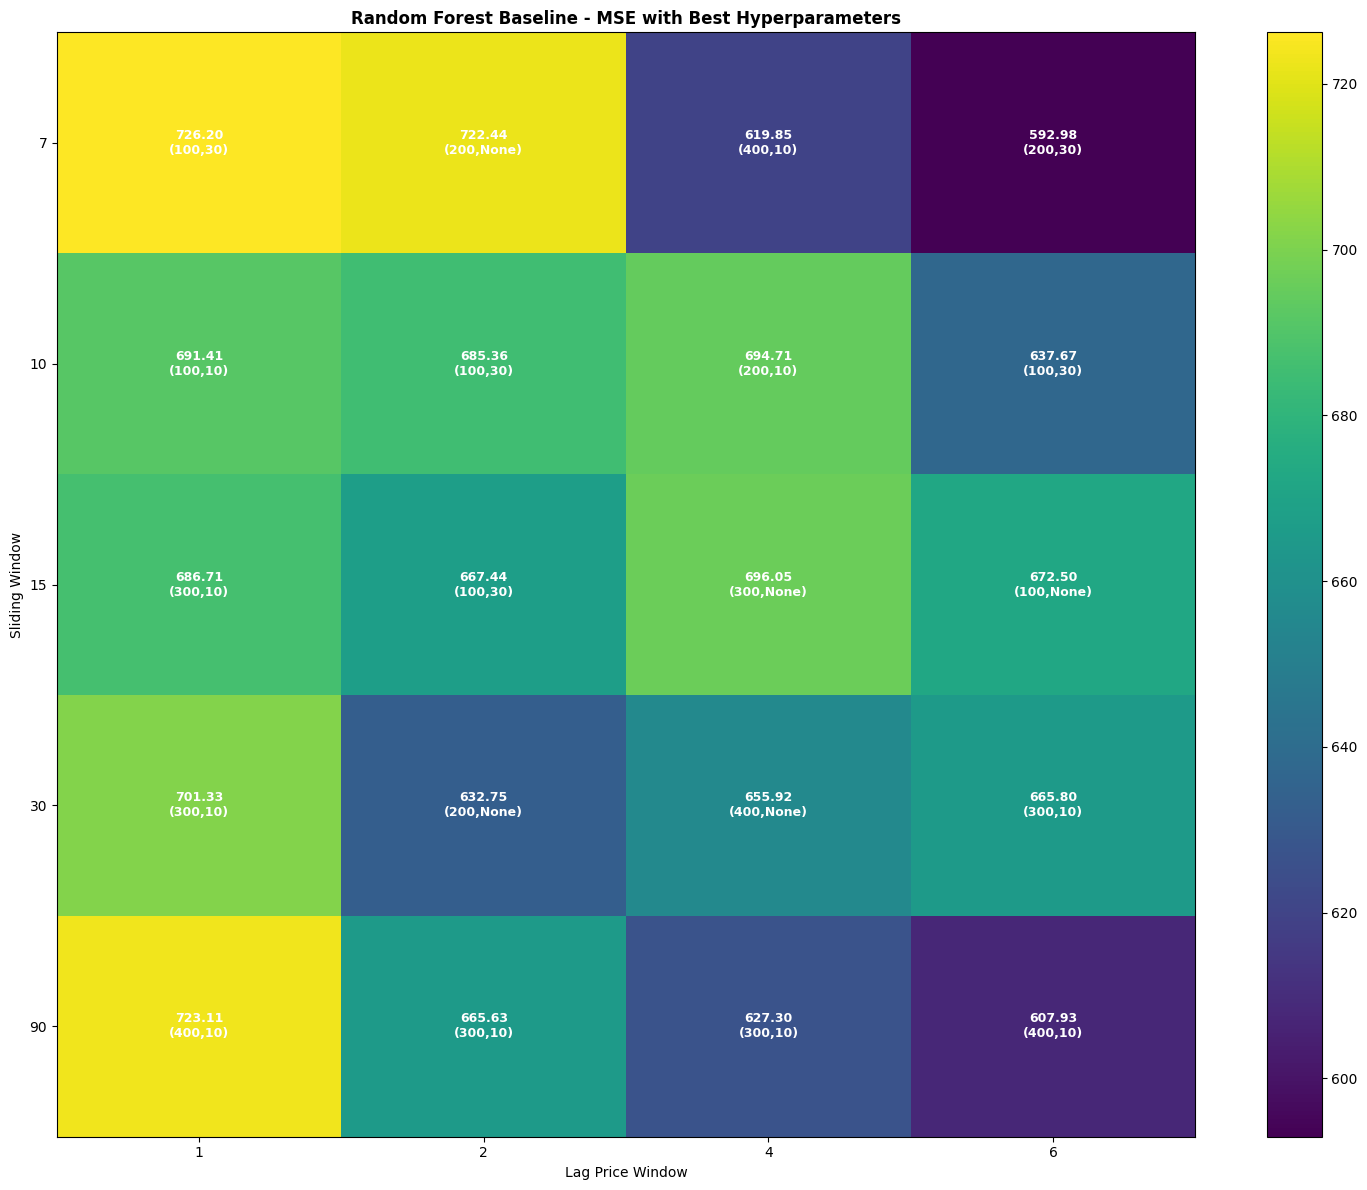

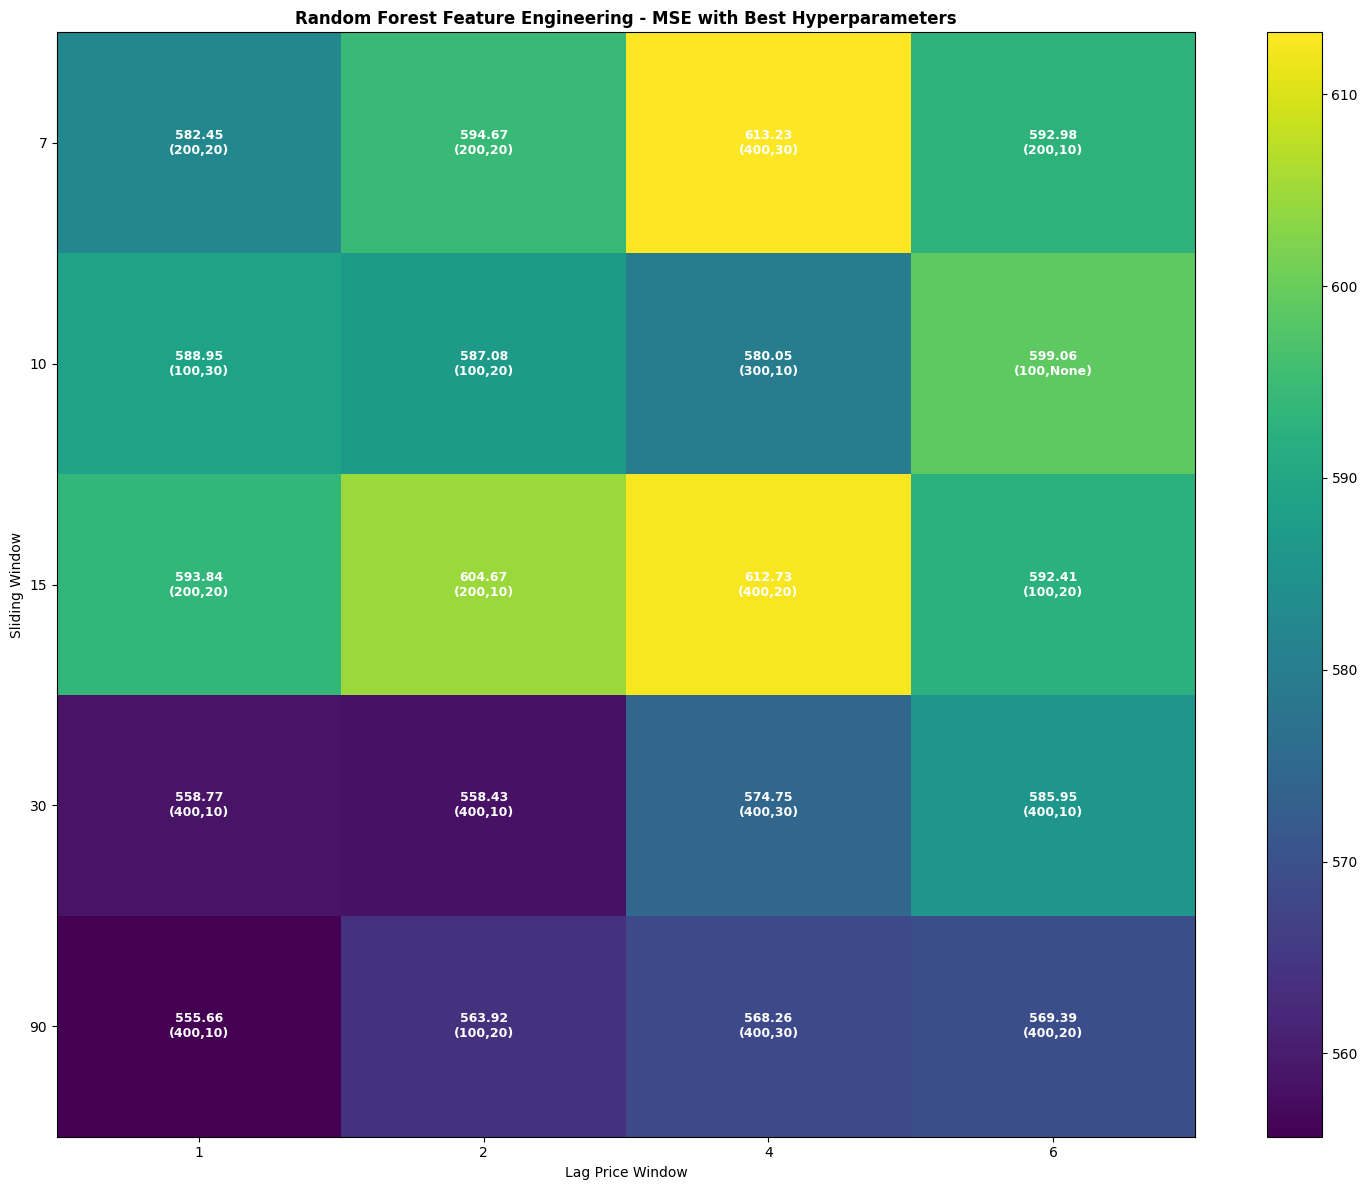

In [139]:
# Alternative: Annotated view for specific metrics
plot_rf_annotated_heatmap(random_forest_baseline_ranked, 'Random Forest Baseline', 'mse')
plot_rf_annotated_heatmap(random_forest_fe_ranked, 'Random Forest Feature Engineering', 'mse')

# Overall Effect of Feature Engineering Analysis (99th Percentile)

In this section, we'll combine all models' metrics to analyze the overall effect of feature engineering across different algorithms, focusing specifically on the 99th percentile results to evaluate performance under extreme market conditions.

In [150]:
def combine_model_metrics():
    """Combine all models' best metrics into a single DataFrame for comparison - 99th percentile only"""
    
    # Filter for 99th percentile only and get best configurations for each model
    reg_baseline_99 = regression_baseline_ranked[regression_baseline_ranked['percentile'] == 99]
    reg_fe_99 = regression_fe_ranked[regression_fe_ranked['percentile'] == 99]
    lasso_baseline_99 = lasso_baseline_ranked[lasso_baseline_ranked['percentile'] == 99]
    lasso_fe_99 = lasso_fe_ranked[lasso_fe_ranked['percentile'] == 99]
    rf_baseline_99 = random_forest_baseline_ranked[random_forest_baseline_ranked['percentile'] == 99]
    rf_fe_99 = random_forest_fe_ranked[random_forest_fe_ranked['percentile'] == 99]
    
    # Get best configurations for each model (99th percentile only)
    reg_baseline_best = reg_baseline_99.loc[reg_baseline_99.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    reg_fe_best = reg_fe_99.loc[reg_fe_99.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    lasso_baseline_best = lasso_baseline_99.loc[lasso_baseline_99.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    lasso_fe_best = lasso_fe_99.loc[lasso_fe_99.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    rf_baseline_best = rf_baseline_99.loc[rf_baseline_99.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    rf_fe_best = rf_fe_99.loc[rf_fe_99.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    # Add model type and feature engineering status
    reg_baseline_best['model'] = 'Regression'
    reg_baseline_best['fe_status'] = 'Baseline'
    reg_fe_best['model'] = 'Regression'
    reg_fe_best['fe_status'] = 'Feature Engineering'
    
    lasso_baseline_best['model'] = 'Lasso'
    lasso_baseline_best['fe_status'] = 'Baseline'
    lasso_fe_best['model'] = 'Lasso'
    lasso_fe_best['fe_status'] = 'Feature Engineering'
    
    rf_baseline_best['model'] = 'Random Forest'
    rf_baseline_best['fe_status'] = 'Baseline'
    rf_fe_best['model'] = 'Random Forest'
    rf_fe_best['fe_status'] = 'Feature Engineering'
    
    # Select relevant columns for comparison
    metrics_cols = ['sliding_window', 'lag_price_window', 'mae', 'mse', 'r2', 'worst_avg_error', 'model', 'fe_status']
    
    # Combine all dataframes
    combined_df = pd.concat([
        reg_baseline_best[metrics_cols],
        reg_fe_best[metrics_cols],
        lasso_baseline_best[metrics_cols],
        lasso_fe_best[metrics_cols],
        rf_baseline_best[metrics_cols],
        rf_fe_best[metrics_cols]
    ], ignore_index=True)
    
    return combined_df

# Create the combined dataset
combined_metrics = combine_model_metrics()
print("Combined metrics shape:", combined_metrics.shape)
print("\nFirst few rows:")
print(combined_metrics.head(10))

Combined metrics shape: (120, 8)

First few rows:
   sliding_window  lag_price_window        mae          mse        r2  \
0               7                 1  17.904767   775.961102  0.766035   
1               7                 2  23.742913  1480.667507  0.557800   
2               7                 4  22.807521  1379.531459  0.589836   
3               7                 6  15.062360   592.975588  0.819059   
4              10                 1  16.033917   614.071813  0.810896   
5              10                 2  17.797488   781.782627  0.762440   
6              10                 4  36.838284  4215.763465 -0.262093   
7              10                 6  21.562117  1121.405049  0.657833   
8              15                 1  15.604518   562.821588  0.826029   
9              15                 2  16.695334   642.847866  0.806179   

   worst_avg_error       model fe_status  
0        84.766355  Regression  Baseline  
1       121.322145  Regression  Baseline  
2       116.16018

In [151]:
def calculate_fe_effect(combined_df):
    """Calculate the effect of feature engineering for each model and configuration"""
    
    # Create pivot tables for baseline and FE results
    baseline_df = combined_df[combined_df['fe_status'] == 'Baseline'].copy()
    fe_df = combined_df[combined_df['fe_status'] == 'Feature Engineering'].copy()
    
    # Merge baseline and FE results for direct comparison
    comparison_df = baseline_df.merge(
        fe_df, 
        on=['sliding_window', 'lag_price_window', 'model'], 
        suffixes=('_baseline', '_fe')
    )
    
    # Calculate improvements (negative values indicate improvement for MAE, MSE, worst_error)
    # Positive values indicate improvement for R²
    comparison_df['mae_improvement'] = ((comparison_df['mae_baseline'] - comparison_df['mae_fe']) / comparison_df['mae_baseline']) * 100
    comparison_df['mse_improvement'] = ((comparison_df['mse_baseline'] - comparison_df['mse_fe']) / comparison_df['mse_baseline']) * 100
    comparison_df['r2_improvement'] = ((comparison_df['r2_fe'] - comparison_df['r2_baseline']) / abs(comparison_df['r2_baseline'])) * 100
    comparison_df['worst_error_improvement'] = ((comparison_df['worst_avg_error_baseline'] - comparison_df['worst_avg_error_fe']) / comparison_df['worst_avg_error_baseline']) * 100
    
    return comparison_df

# Calculate feature engineering effects
fe_effects = calculate_fe_effect(combined_metrics)
print("Feature Engineering Effects Analysis:")
print(f"Shape: {fe_effects.shape}")
print("\nSample of improvements (positive values = better performance):")
print(fe_effects[['model', 'sliding_window', 'lag_price_window', 
                  'mae_improvement', 'mse_improvement', 'r2_improvement', 'worst_error_improvement']].head())

Feature Engineering Effects Analysis:
Shape: (60, 17)

Sample of improvements (positive values = better performance):
        model  sliding_window  lag_price_window  mae_improvement  \
0  Regression               7                 1      -152.924089   
1  Regression               7                 2       -74.490345   
2  Regression               7                 4        -9.892124   
3  Regression               7                 6         0.000000   
4  Regression              10                 1      -271.040657   

   mse_improvement  r2_improvement  worst_error_improvement  
0     -1659.385612     -493.383789              -355.486958  
1      -783.101353     -605.279362              -198.597488  
2       -54.316199      -35.966686               -30.584637  
3         0.000000        0.000000                 0.000000  
4     -5566.017920    -1230.154537              -688.434960  


In [152]:
# Summary statistics for each model
def summarize_fe_effects(fe_effects_df):
    """Generate summary statistics for feature engineering effects"""
    
    summary_stats = []
    
    for model in fe_effects_df['model'].unique():
        model_data = fe_effects_df[fe_effects_df['model'] == model]
        
        stats = {
            'Model': model,
            'MAE_Improvement_Mean': model_data['mae_improvement'].mean(),
            'MAE_Improvement_Std': model_data['mae_improvement'].std(),
            'MSE_Improvement_Mean': model_data['mse_improvement'].mean(),
            'MSE_Improvement_Std': model_data['mse_improvement'].std(),
            'R2_Improvement_Mean': model_data['r2_improvement'].mean(),
            'R2_Improvement_Std': model_data['r2_improvement'].std(),
            'Worst_Error_Improvement_Mean': model_data['worst_error_improvement'].mean(),
            'Worst_Error_Improvement_Std': model_data['worst_error_improvement'].std(),
            'Configs_Improved_MAE': (model_data['mae_improvement'] > 0).sum(),
            'Configs_Improved_MSE': (model_data['mse_improvement'] > 0).sum(),
            'Configs_Improved_R2': (model_data['r2_improvement'] > 0).sum(),
            'Configs_Improved_Worst': (model_data['worst_error_improvement'] > 0).sum(),
            'Total_Configs': len(model_data)
        }
        summary_stats.append(stats)
    
    return pd.DataFrame(summary_stats)

# Generate summary
fe_summary = summarize_fe_effects(fe_effects)
print("=== FEATURE ENGINEERING EFFECTS SUMMARY (99th Percentile) ===")
print("(Positive values indicate improvement)")
print("\nMean Improvements by Model:")
for idx, row in fe_summary.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  MAE: {row['MAE_Improvement_Mean']:+.2f}% (±{row['MAE_Improvement_Std']:.2f}%)")
    print(f"  MSE: {row['MSE_Improvement_Mean']:+.2f}% (±{row['MSE_Improvement_Std']:.2f}%)")
    print(f"  R²:  {row['R2_Improvement_Mean']:+.2f}% (±{row['R2_Improvement_Std']:.2f}%)")
    print(f"  Worst Error: {row['Worst_Error_Improvement_Mean']:+.2f}% (±{row['Worst_Error_Improvement_Std']:.2f}%)")
    print(f"  Configs Improved: {row['Configs_Improved_MAE']}/{row['Total_Configs']} (MAE), {row['Configs_Improved_R2']}/{row['Total_Configs']} (R²)")

=== FEATURE ENGINEERING EFFECTS SUMMARY (99th Percentile) ===
(Positive values indicate improvement)

Mean Improvements by Model:

Regression:
  MAE: -150.55% (±129.58%)
  MSE: -1657.07% (±1800.90%)
  R²:  -542.72% (±525.72%)
  Worst Error: -301.47% (±251.19%)
  Configs Improved: 0/20 (MAE), 0/20 (R²)

Lasso:
  MAE: -5.91% (±6.27%)
  MSE: -9.27% (±8.49%)
  R²:  -1.99% (±1.57%)
  Worst Error: -2.86% (±3.76%)
  Configs Improved: 2/20 (MAE), 3/20 (R²)

Random Forest:
  MAE: +5.33% (±2.90%)
  MSE: +12.39% (±5.96%)
  R²:  +3.46% (±1.70%)
  Worst Error: +7.07% (±3.83%)
  Configs Improved: 19/20 (MAE), 19/20 (R²)


/var/folders/wp/4485d5tx6llgsc8d158gbw500000gn/T/ipykernel_29622/1638045669.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0, 0].boxplot(mae_improvements, labels=models, patch_artist=True)
/var/folders/wp/4485d5tx6llgsc8d158gbw500000gn/T/ipykernel_29622/1638045669.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0, 1].boxplot(mse_improvements, labels=models, patch_artist=True)
/var/folders/wp/4485d5tx6llgsc8d158gbw500000gn/T/ipykernel_29622/1638045669.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[0, 2].boxplot(r2_improvements, labels=models, patch_artist=True)
/var/fol

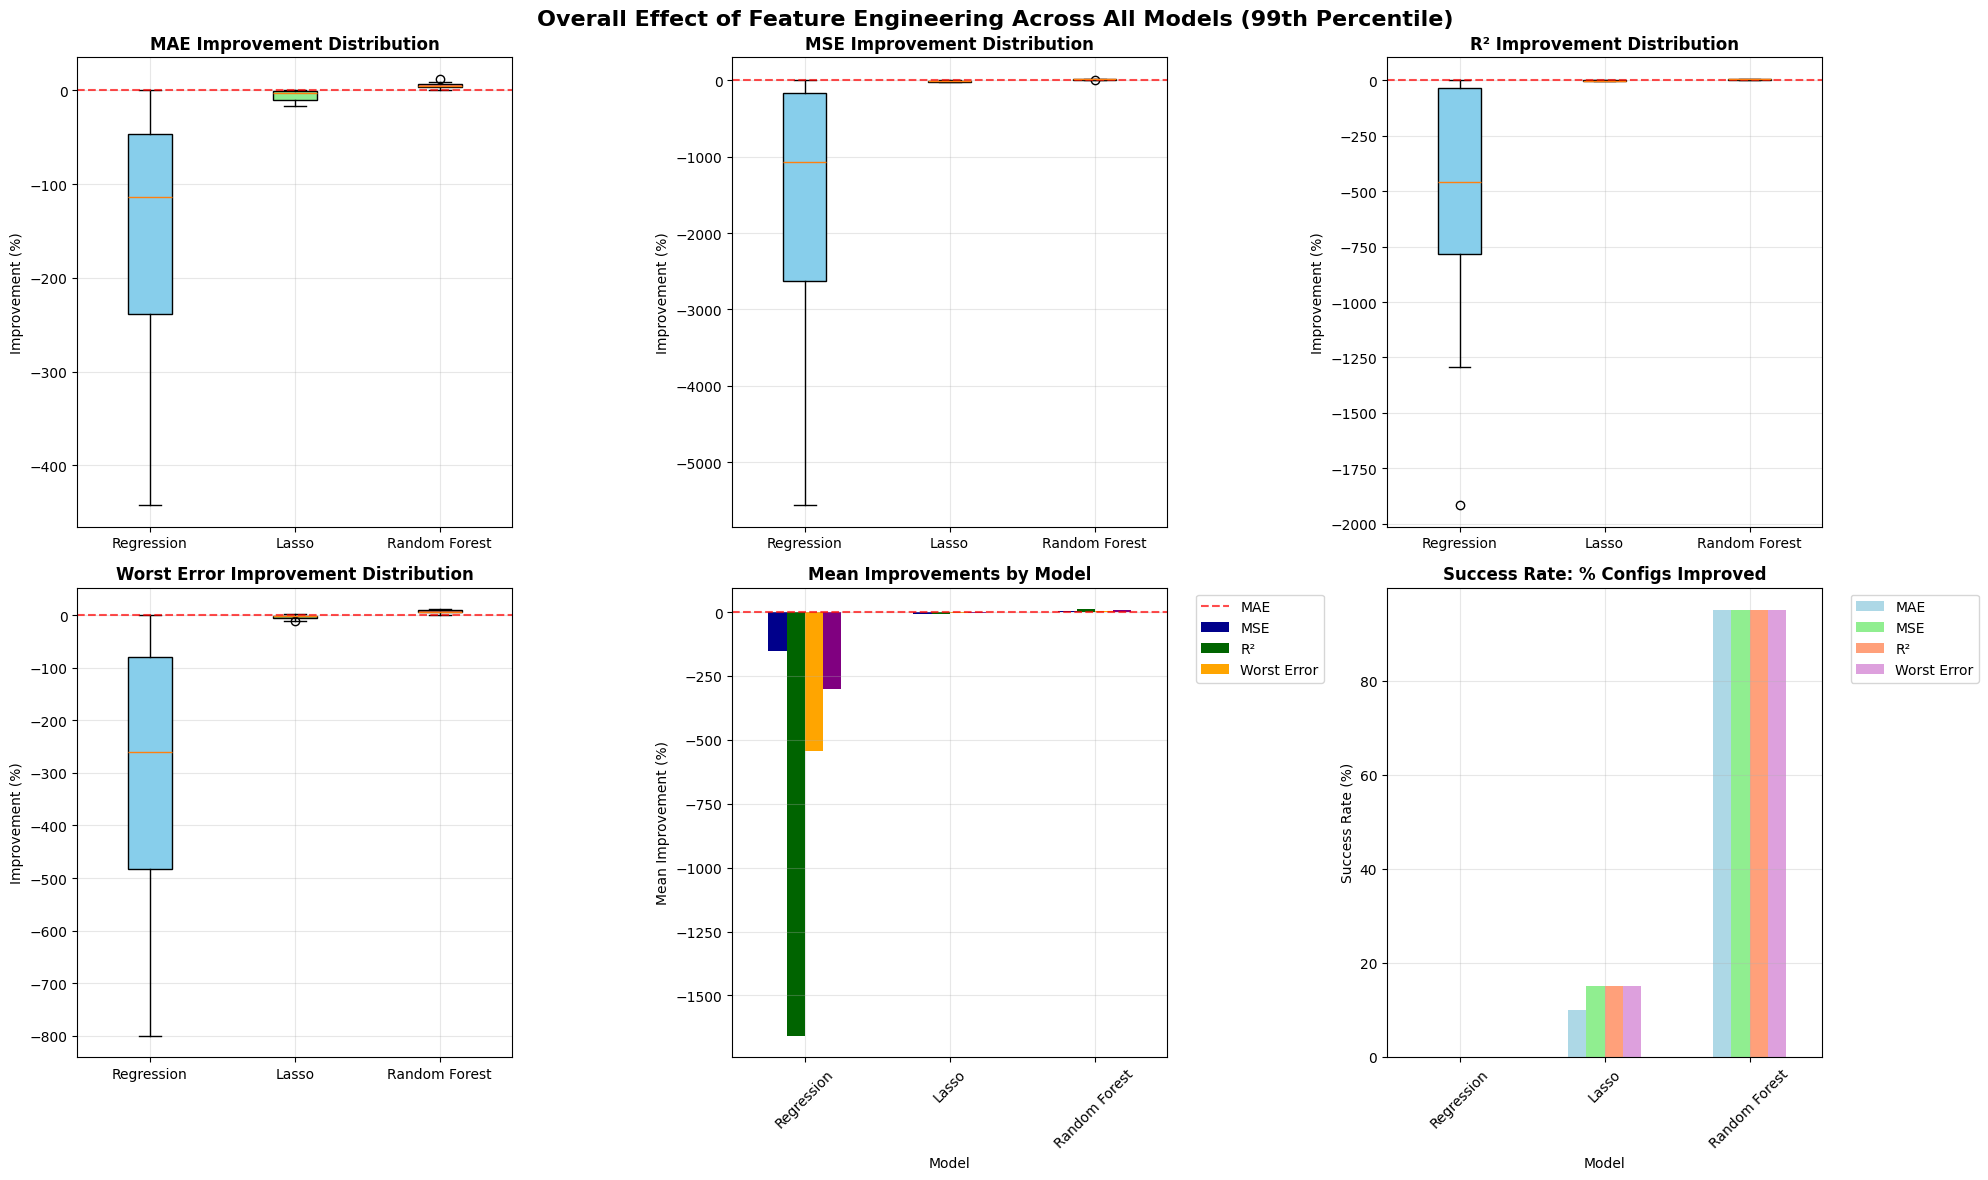

In [153]:
def plot_overall_fe_effects(fe_effects_df, figsize=(20, 12)):
    """Plot comprehensive visualization of feature engineering effects"""
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle('Overall Effect of Feature Engineering Across All Models (99th Percentile)', fontsize=16, fontweight='bold')
    
    models = fe_effects_df['model'].unique()
    colors = ['skyblue', 'lightgreen', 'salmon']
    
    # 1. MAE Improvement by Model
    mae_improvements = [fe_effects_df[fe_effects_df['model'] == model]['mae_improvement'].values for model in models]
    bp1 = axes[0, 0].boxplot(mae_improvements, labels=models, patch_artist=True)
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
    axes[0, 0].set_title('MAE Improvement Distribution', fontweight='bold')
    axes[0, 0].set_ylabel('Improvement (%)')
    axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. MSE Improvement by Model
    mse_improvements = [fe_effects_df[fe_effects_df['model'] == model]['mse_improvement'].values for model in models]
    bp2 = axes[0, 1].boxplot(mse_improvements, labels=models, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
    axes[0, 1].set_title('MSE Improvement Distribution', fontweight='bold')
    axes[0, 1].set_ylabel('Improvement (%)')
    axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. R² Improvement by Model
    r2_improvements = [fe_effects_df[fe_effects_df['model'] == model]['r2_improvement'].values for model in models]
    bp3 = axes[0, 2].boxplot(r2_improvements, labels=models, patch_artist=True)
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
    axes[0, 2].set_title('R² Improvement Distribution', fontweight='bold')
    axes[0, 2].set_ylabel('Improvement (%)')
    axes[0, 2].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Worst Error Improvement by Model
    worst_improvements = [fe_effects_df[fe_effects_df['model'] == model]['worst_error_improvement'].values for model in models]
    bp4 = axes[1, 0].boxplot(worst_improvements, labels=models, patch_artist=True)
    for patch, color in zip(bp4['boxes'], colors):
        patch.set_facecolor(color)
    axes[1, 0].set_title('Worst Error Improvement Distribution', fontweight='bold')
    axes[1, 0].set_ylabel('Improvement (%)')
    axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Mean improvements bar chart
    mean_improvements = fe_summary[['Model', 'MAE_Improvement_Mean', 'MSE_Improvement_Mean', 
                                   'R2_Improvement_Mean', 'Worst_Error_Improvement_Mean']].set_index('Model')
    mean_improvements.plot(kind='bar', ax=axes[1, 1], color=['darkblue', 'darkgreen', 'orange', 'purple'])
    axes[1, 1].set_title('Mean Improvements by Model', fontweight='bold')
    axes[1, 1].set_ylabel('Mean Improvement (%)')
    axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].legend(['MAE', 'MSE', 'R²', 'Worst Error'], bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    # 6. Improvement success rate
    success_rates = fe_summary[['Model', 'Configs_Improved_MAE', 'Configs_Improved_MSE', 
                               'Configs_Improved_R2', 'Configs_Improved_Worst', 'Total_Configs']].copy()
    
    for metric in ['MAE', 'MSE', 'R2', 'Worst']:
        success_rates[f'{metric}_Rate'] = (success_rates[f'Configs_Improved_{metric}'] / success_rates['Total_Configs']) * 100
    
    success_rates[['Model', 'MAE_Rate', 'MSE_Rate', 'R2_Rate', 'Worst_Rate']].set_index('Model').plot(
        kind='bar', ax=axes[1, 2], color=['lightblue', 'lightgreen', 'lightsalmon', 'plum'])
    axes[1, 2].set_title('Success Rate: % Configs Improved', fontweight='bold')
    axes[1, 2].set_ylabel('Success Rate (%)')
    axes[1, 2].legend(['MAE', 'MSE', 'R²', 'Worst Error'], bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('overall_effect_of_FE.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create the comprehensive visualization
plot_overall_fe_effects(fe_effects)

AttributeError: 'numpy.ndarray' object has no attribute 'set_title'

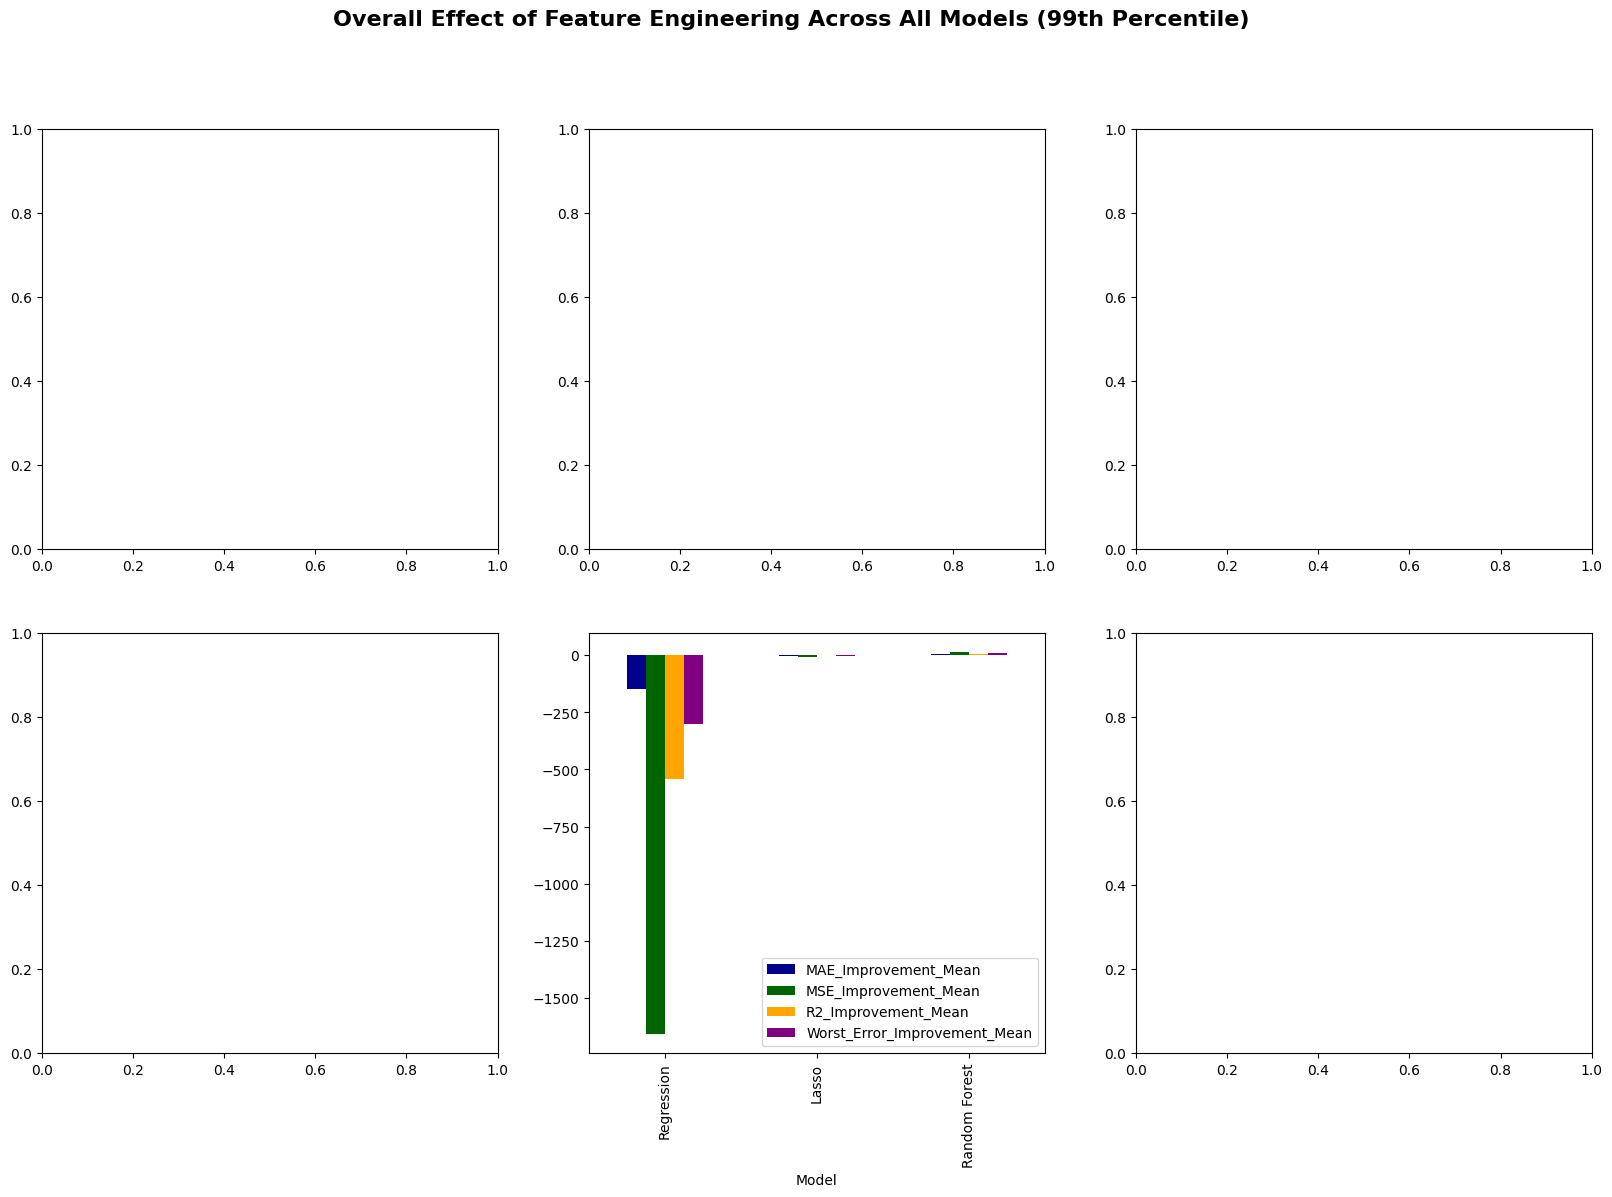

In [156]:
# # Plot two figures side by side for better comparison
# def plot_mean_and_success_rate_fe_effects(fe_effects_df, figsize=(20, 12)):
#     """Plot comprehensive visualization of feature engineering effects"""
    
#     fig, axes = plt.subplots(2, 3, figsize=figsize)
#     fig.suptitle('Overall Effect of Feature Engineering Across All Models (99th Percentile)', fontsize=16, fontweight='bold')
    
#     models = fe_effects_df['model'].unique()
#     colors = ['skyblue', 'lightgreen', 'salmon']

#     # 5. Mean improvements bar chart
#     mean_improvements = fe_summary[['Model', 'MAE_Improvement_Mean', 'MSE_Improvement_Mean', 
#                                    'R2_Improvement_Mean', 'Worst_Error_Improvement_Mean']].set_index('Model')
#     mean_improvements.plot(kind='bar', ax=axes[1, 1], color=['darkblue', 'darkgreen', 'orange', 'purple'])
#     axes[1].set_title('Mean Improvements by Model', fontweight='bold')
#     axes[1].set_ylabel('Mean Improvement (%)')
#     axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
#     axes[1].legend(['MAE', 'MSE', 'R²', 'Worst Error'], bbox_to_anchor=(1.05, 1), loc='upper left')
#     axes[1].grid(True, alpha=0.3)
#     axes[1].tick_params(axis='x', rotation=45)
    
#     # 6. Improvement success rate
#     success_rates = fe_summary[['Model', 'Configs_Improved_MAE', 'Configs_Improved_MSE', 
#                                'Configs_Improved_R2', 'Configs_Improved_Worst', 'Total_Configs']].copy()
    
#     for metric in ['MAE', 'MSE', 'R2', 'Worst']:
#         success_rates[f'{metric}_Rate'] = (success_rates[f'Configs_Improved_{metric}'] / success_rates['Total_Configs']) * 100
    
#     success_rates[['Model', 'MAE_Rate', 'MSE_Rate', 'R2_Rate', 'Worst_Rate']].set_index('Model').plot(
#         kind='bar', ax=axes[1, 2], color=['lightblue', 'lightgreen', 'lightsalmon', 'plum'])
#     axes[2].set_title('Success Rate: % Configs Improved', fontweight='bold')
#     axes[2].set_ylabel('Success Rate (%)')
#     axes[2].legend(['MAE', 'MSE', 'R²', 'Worst Error'], bbox_to_anchor=(1.05, 1), loc='upper left')
#     axes[2].grid(True, alpha=0.3)
#     axes[2].tick_params(axis='x', rotation=45)
#     plt.tight_layout()
#     plt.savefig('mean_and_success_rate_fe_effects.png', dpi=300, bbox_inches='tight')
#     plt.show()


# plot_mean_and_success_rate_fe_effects(fe_effects)


In [149]:
# Create detailed comparison tables
def create_detailed_fe_analysis():
    """Create detailed analysis tables for feature engineering effects"""
    
    # Overall summary table
    print("=== DETAILED FEATURE ENGINEERING ANALYSIS (99th Percentile) ===\n")
    
    # 1. Best and worst performing configurations for each model
    print("1. BEST AND WORST FE EFFECTS BY MODEL:")
    for model in fe_effects['model'].unique():
        model_data = fe_effects[fe_effects['model'] == model]
        
        print(f"\n{model}:")
        
        # Best MAE improvement
        best_mae = model_data.loc[model_data['mae_improvement'].idxmax()]
        print(f"  Best MAE improvement: {best_mae['mae_improvement']:.2f}% "
              f"(SW:{best_mae['sliding_window']}, LPW:{best_mae['lag_price_window']})")
        
        # Worst MAE improvement
        worst_mae = model_data.loc[model_data['mae_improvement'].idxmin()]
        print(f"  Worst MAE change: {worst_mae['mae_improvement']:.2f}% "
              f"(SW:{worst_mae['sliding_window']}, LPW:{worst_mae['lag_price_window']})")
        
        # Best R² improvement
        best_r2 = model_data.loc[model_data['r2_improvement'].idxmax()]
        print(f"  Best R² improvement: {best_r2['r2_improvement']:.2f}% "
              f"(SW:{best_r2['sliding_window']}, LPW:{best_r2['lag_price_window']})")
    
    # 2. Configuration-wise analysis
    print("\n\n2. CONFIGURATION-WISE FE EFFECTS:")
    config_summary = fe_effects.groupby(['sliding_window', 'lag_price_window']).agg({
        'mae_improvement': ['mean', 'std', 'min', 'max'],
        'r2_improvement': ['mean', 'std', 'min', 'max']
    }).round(2)
    
    print("\nMAE Improvement by Configuration:")
    print(config_summary['mae_improvement'])
    print("\nR² Improvement by Configuration:")
    print(config_summary['r2_improvement'])
    
    # 3. Statistical significance (simple analysis)
    print("\n\n3. STATISTICAL OVERVIEW:")
    overall_stats = {
        'Total Configurations Tested': len(fe_effects),
        'Configurations with MAE Improvement': (fe_effects['mae_improvement'] > 0).sum(),
        'Configurations with MSE Improvement': (fe_effects['mse_improvement'] > 0).sum(),
        'Configurations with R² Improvement': (fe_effects['r2_improvement'] > 0).sum(),
        'Configurations with Worst Error Improvement': (fe_effects['worst_error_improvement'] > 0).sum(),
        'Mean MAE Improvement': fe_effects['mae_improvement'].mean(),
        'Mean R² Improvement': fe_effects['r2_improvement'].mean()
    }
    
    for key, value in overall_stats.items():
        if isinstance(value, (int, float)):
            if 'Mean' in key:
                print(f"{key}: {value:+.2f}%")
            else:
                print(f"{key}: {value}")
        else:
            print(f"{key}: {value}")

# Run the detailed analysis
create_detailed_fe_analysis()

# Export results to CSV for further analysis
print("\n\n=== EXPORTING RESULTS ===")
fe_effects.to_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/feature_engineering_effects_analysis.csv', index=False)
fe_summary.to_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/feature_engineering_summary.csv', index=False)
combined_metrics.to_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/combined_all_models_metrics.csv', index=False)

print("✓ Exported feature_engineering_effects_analysis.csv")
print("✓ Exported feature_engineering_summary.csv") 
print("✓ Exported combined_all_models_metrics.csv")

=== DETAILED FEATURE ENGINEERING ANALYSIS ===

1. BEST AND WORST FE EFFECTS BY MODEL:

Regression:
  Best MAE improvement: 0.00% (SW:7, LPW:6)
  Worst MAE change: -442.44% (SW:30, LPW:1)
  Best R² improvement: 0.00% (SW:7, LPW:6)

Lasso:
  Best MAE improvement: 0.38% (SW:7, LPW:2)
  Worst MAE change: -16.89% (SW:90, LPW:1)
  Best R² improvement: 0.36% (SW:7, LPW:4)

Random Forest:
  Best MAE improvement: 12.51% (SW:90, LPW:1)
  Worst MAE change: 0.00% (SW:7, LPW:6)
  Best R² improvement: 6.55% (SW:90, LPW:1)


2. CONFIGURATION-WISE FE EFFECTS:

MAE Improvement by Configuration:
                                   mean     std     min    max
sliding_window lag_price_window                               
7              1                 -48.53   90.53 -152.92   8.31
               2                 -22.38   45.25  -74.49   6.97
               4                  -3.18    5.82   -9.89   0.25
               6                   0.00    0.00    0.00   0.00
10             1                 -90.